# Spatial Proteomics of Murine Acute Kidney Injury

**The question.** Unilateral ureteral obstruction (UUO) in mice produces a stereotyped injury trajectory: neutrophil infiltration within hours, myeloid expansion by days, fibroblast activation and interstitial remodeling by the end of the first week. Does that trajectory show up in spatial protein architecture at tissue-patch resolution clearly enough for a small cohort to surface candidate findings worth powering in a larger study?

**What we did.** Imaging Mass Cytometry (IMC) on 24 regions of interest from 8 mice (n=2 per timepoint at Sham, D1, D3, D7), using a nine-marker panel covering the five biological axes of AKI: immune infiltration (CD45, CD11b, Ly6G), myeloid polarization (CD206), vascular integrity (CD31, CD34), mesenchymal/fibrotic response (CD140a, CD140b), and tissue injury/adhesion (CD44). The IMC output is a stack of per-pixel ion-count images, which we segment into ~10 µm tissue patches — each patch is the unit of analysis in everything below. Each patch is annotated two ways in parallel: discrete cell type labels (15 categories via boolean gating rules) and continuous lineage memberships (three non-exclusive scores for immune, endothelial, and stromal character). Three pre-registered endpoint families compare these annotations across timepoints.

**Candidate finding.** Between Sham and Day 7, stromal-marker-positive tissue appears less *stromal-only* and more *multi-lineage*. The triple-positive category (patches scoring on all three lineages simultaneously — immune + endothelial + stromal) rises; tissue not assigned to any named compartment acquires broad CD44⁺ injury-marker activation. This converges from two non-identical analytical lenses and is an observation worth testing in a powered follow-up, not a tested claim.

**What this notebook is for.** §1–§5 visualize the per-patch annotations — who the cell types are, how they distribute, what neighborhoods they occupy, how published biology connects the panel markers. §6 synthesizes the pre-registered effect-size analysis (narrated from `endpoint_summary.csv`, 618 endpoint rows; Phase 6 dual-basis Family B). §7 converts the effect sizes into sample-size requirements for a powered follow-up. The companion kidney notebook (`notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb`) carries the visualizations of the §6 effect-size endpoints.

**Honest scope.** At n=2 mice per timepoint, no statistical test can reach conventional significance (Mann-Whitney U produces only three possible p-values: ~0.33, 0.67, 1.0). We report effect sizes (Hedges' g) with Bayesian shrinkage under three explicit priors on how skeptical to be about pilot effects; the range is the finding, not any single number. Phase 1 closed the per-ROI normalization seam the earlier version of this notebook flagged: `compute_continuous_memberships` now centers its sigmoid on a Sham-pooled per-mouse reference (artifact: `results/biological_analysis/sham_reference_10.0um.json`) rather than self-normalizing within each ROI. Under the re-run, the candidate finding is **direction-consistent across two non-identical normalization paths** (Sham-reference sigmoid and raw-marker Sham-reference percentile): 0/35 Family A endpoints sign-reverse at |g|>0.5, and 13/48 disagree by ≥2× in magnitude, which sets the honest upper bound on how much of the effect is method-dependent rather than biological.

**Pre-registration:** `analysis_plans/temporal_interfaces_plan.md` (frozen 2026-04-17, amended through 2026-04-20).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import networkx as nx
from pathlib import Path
import sys

# --- Project root discovery ---
_candidates = [Path().resolve()] + [Path().resolve().parents[i] for i in range(5)]
project_root = None
for _c in _candidates:
    if (_c / 'config.json').exists():
        project_root = _c
        break
assert project_root is not None, 'Could not find project root (no config.json)'
sys.path.insert(0, str(project_root))

# --- Analysis config (cell type gating rules, family lineage map) ---
with open(project_root / 'config.json') as f:
    config = json.load(f)

# --- Display config (colors, labels, plot defaults) lives in viz.json ---
from src.viz_utils import VizConfig
viz = VizConfig.load(project_root / 'viz.json')
viz.apply_rcparams()

# Shorthand for the plot code below
CT_COLORS = viz.cell_type_colors
CT_LABELS = viz.cell_type_labels
CT_ORDER  = viz.cell_type_order
TP_ORDER  = viz.timepoint_order
TP_COLORS = viz.timepoint_colors

GENE_AXIS_COLOR = {
    'PTPRC': '#E63946', 'ITGAM': '#E63946', 'Ly6g': '#D62828',
    'MRC1': '#FCBF49', 'PDGFRA': '#2A9D8F', 'PDGFRB': '#2A9D8F',
    'PECAM1': '#457B9D', 'CD34': '#06AED5', 'CD44': '#9B59B6',
}
GENE_AXIS_LABEL = {
    'PTPRC': 'Immune', 'ITGAM': 'Immune', 'Ly6g': 'Immune',
    'MRC1': 'Immune', 'PDGFRA': 'Stromal', 'PDGFRB': 'Stromal',
    'PECAM1': 'Vascular', 'CD34': 'Vascular', 'CD44': 'Injury/Adhesion',
}

# --- Load all data ---
bio_dir = project_root / 'results' / 'biological_analysis'
da_dir = bio_dir / 'differential_abundance'
sp_dir = bio_dir / 'spatial_neighborhoods'

temporal_da = pd.read_csv(da_dir / 'temporal_differential_abundance.csv')  # Layer A: 15 config cell types
regional_da = pd.read_csv(da_dir / 'regional_differential_abundance.csv')
try:
    temporal_rollups = pd.read_csv(da_dir / 'temporal_lineage_rollups.csv')  # Layer B: 3 lineage axes + 5 subtype aggregates
except FileNotFoundError:
    temporal_rollups = pd.DataFrame()
roi_abundances = pd.read_csv(da_dir / 'roi_abundances.csv')
temporal_enrich = pd.read_csv(sp_dir / 'temporal_neighborhood_enrichments.csv')
regional_enrich = pd.read_csv(sp_dir / 'regional_neighborhood_enrichments.csv')
indra_annot = pd.read_csv(bio_dir / 'indra_finding_annotations.csv')

with open(bio_dir / 'indra_panel_context.json') as f:
    indra_ctx = json.load(f)

try:
    power_df = pd.read_csv(project_root / 'results' / 'power_analysis' / 'sample_size_requirements.csv')
except FileNotFoundError:
    power_df = None

# Ensure timepoint ordering
temporal_da['timepoint_1'] = pd.Categorical(temporal_da['timepoint_1'], categories=TP_ORDER, ordered=True)
roi_abundances['timepoint'] = pd.Categorical(roi_abundances['timepoint'], categories=TP_ORDER, ordered=True)
temporal_enrich['timepoint'] = pd.Categorical(temporal_enrich['timepoint'], categories=TP_ORDER, ordered=True)

def ct_label(ct):
    return viz.ct_label(ct)

print(f'Loaded: {len(temporal_da)} temporal DA, {len(regional_da)} regional DA, '
      f'{len(roi_abundances)} ROIs, {len(temporal_enrich)} enrichments, '
      f'{len(indra_annot)} INDRA annotations')


Loaded: 90 temporal DA, 45 regional DA, 24 ROIs, 900 enrichments, 79 INDRA annotations


---
## 1. Study Design

| Parameter | Value |
|-----------|-------|
| Species | Mouse (C57BL/6) |
| Model | Unilateral ureteral obstruction (UUO) — ligation of one ureter induces progressive fibrosis in the obstructed kidney |
| Timepoints | Sham (surgery, no ligation) · Day 1 (acute inflammation) · Day 3 (myeloid expansion peak) · Day 7 (early fibrotic remodeling) |
| Biological replicates | n=2 mice per timepoint (8 mice total) |
| ROIs | 24 (~3 per mouse; cortex and medulla sampled) |
| Markers | 9 protein channels via IMC |
| Segmentation | SLIC superpixels at 10 µm (pinned a priori; plan §2) |
| Cell typing | Dual: discrete boolean gating (15 types) + continuous multi-label memberships (3 lineage axes) |
| Design | Cross-sectional (different mice per timepoint, not longitudinal) |

### What the panel is set up to see

| Marker | Gene | Biological signal in UUO |
|---|---|---|
| CD45 | PTPRC | pan-leukocyte; rises with immune infiltration |
| CD11b | ITGAM | myeloid cells — neutrophils, monocytes, macrophages |
| Ly6G | Ly6g | murine neutrophils specifically |
| CD206 | MRC1 | alternatively-activated (M2) macrophages; resolution-phase marker |
| CD31 | PECAM1 | endothelium; vascular rarefaction tracks injury |
| CD34 | CD34 | endothelial progenitors / hematopoietic stem cells |
| CD140a | PDGFRA | fibroblast lineage anchor in this pipeline |
| CD140b | PDGFRB | pericytes / activated mesenchymal marker; used as activation overlay |
| CD44 | CD44 | tissue injury / hyaluronan receptor; the only panel gene with direct MESH annotation to AKI |

Panel markers were selected against the INDRA/CoGEx knowledge graph (§5), which captures 117 literature-documented causal relationships among the 8 groundable genes (Ly6g is murine-specific with limited INDRA coverage). Five of the eight are regulated by TGF-β, the master regulator of renal fibrosis.

### What the panel cannot see

9 markers do not cover tubular epithelium (no E-cadherin, no KIM-1, no aquaporin), lymphocyte subsets (no CD3/CD4/CD8/CD20), dendritic cells, or advanced macrophage polarization states. Approximately 77% of tissue superpixels remain unassigned to any discrete cell type — this is a consequence of panel design, not a failure of analysis. The continuous lineage system (next section) recovers part of this tissue by allowing multi-lineage assignment.

In [2]:
# --- 1a. Panel grounding table ---
mg = indra_ctx['marker_grounding']
markers = config['channels']['protein_channels']

axis_map = {
    'CD45': 'Pan-leukocyte', 'CD11b': 'Myeloid', 'Ly6G': 'Neutrophil',
    'CD206': 'M2 macrophage', 'CD140a': 'Fibroblast/mesenchymal',
    'CD140b': 'Pericyte/mural', 'CD31': 'Endothelial',
    'CD34': 'Endothelial progenitor', 'CD44': 'Injury/adhesion',
}

panel_rows = []
for m in markers:
    info = mg.get(m, {})
    gene = info.get('gene_name', '-')
    curie = info.get('curie', '-')
    grounded = info.get('grounded', False)
    # Count INDRA statements involving this gene
    n_stmts = sum(1 for s in indra_ctx['indra_statements']
                  if s['source'] == gene or s['target'] == gene)
    panel_rows.append({
        'Marker': m, 'Gene': gene, 'CURIE': curie,
        'Biological Axis': axis_map.get(m, '-'),
        'Grounded': grounded, 'INDRA Relationships': n_stmts,
    })

panel_df = pd.DataFrame(panel_rows)
print(panel_df.to_string(index=False))
print(f'\nTotal intra-panel INDRA statements: {len(indra_ctx["indra_statements"])}')
print(f'Grounded markers: {panel_df["Grounded"].sum()}/9 '
      f'(Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)')

Marker   Gene          CURIE        Biological Axis  Grounded  INDRA Relationships
  CD45  PTPRC      hgnc:9666          Pan-leukocyte      True                   39
 CD11b  ITGAM      hgnc:6149                Myeloid      True                   35
  Ly6G   Ly6g uniprot:P35461             Neutrophil      True                    9
CD140a PDGFRA      hgnc:8803 Fibroblast/mesenchymal      True                   19
CD140b PDGFRB      hgnc:8804         Pericyte/mural      True                   22
  CD31 PECAM1      hgnc:8823            Endothelial      True                   27
  CD34   CD34      hgnc:1662 Endothelial progenitor      True                   36
 CD206   MRC1      hgnc:7228          M2 macrophage      True                   20
  CD44   CD44      hgnc:1681        Injury/adhesion      True                   27

Total intra-panel INDRA statements: 117
Grounded markers: 9/9 (Ly6G is murine-specific, grounded to UniProt but limited INDRA coverage)


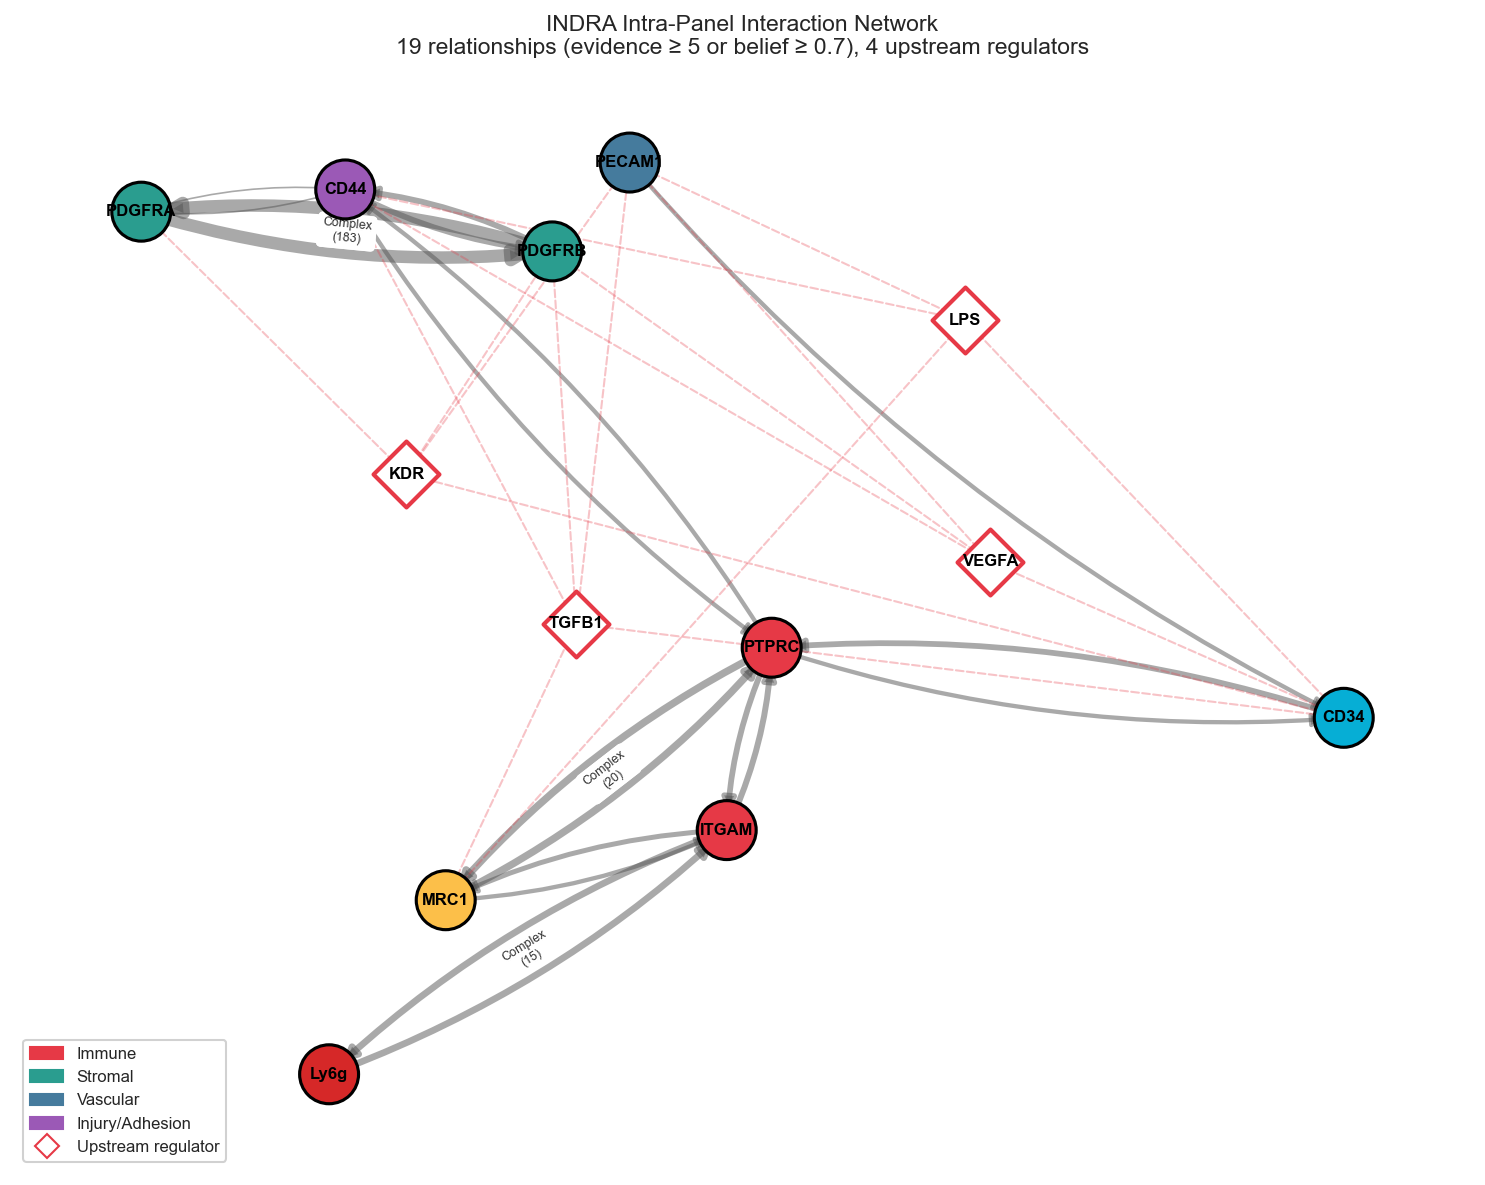

In [3]:
# --- 1b. Panel interaction network ---
stmts = indra_ctx['indra_statements']
regs = indra_ctx['shared_upstream_regulators']

G = nx.DiGraph()

# Add panel gene nodes
panel_genes = set()
for m in markers:
    gene = mg.get(m, {}).get('gene_name', m)
    if gene and gene != '-':
        panel_genes.add(gene)
        G.add_node(gene, node_type='panel')

# Add intra-panel edges (filter: evidence >= 5 or belief >= 0.7)
edge_types = {}
for s in stmts:
    if s['evidence'] >= 5 or s['belief'] >= 0.7:
        key = (s['source'], s['target'])
        if key not in edge_types or s['evidence'] > edge_types[key]['evidence']:
            edge_types[key] = s

for (src, tgt), s in edge_types.items():
    G.add_edge(src, tgt, weight=np.log2(s['evidence'] + 1),
               evidence=s['evidence'], stmt_type=s['type'],
               belief=s['belief'])

# Add top upstream regulators as external nodes
for reg_name, reg_info in regs.items():
    if reg_name not in panel_genes and reg_info['count'] >= 4:
        G.add_node(reg_name, node_type='regulator')
        for tgt in reg_info['targets']:
            if tgt in panel_genes:
                G.add_edge(reg_name, tgt, weight=1.5, evidence=0,
                           stmt_type='Regulation', belief=0.0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

pos = nx.spring_layout(G, k=2.5, seed=42, iterations=80)

# Draw edges
panel_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) > 0]
reg_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('evidence', 0) == 0]
panel_widths = [G[u][v]['weight'] * 0.8 for u, v in panel_edges]

nx.draw_networkx_edges(G, pos, edgelist=panel_edges, width=panel_widths,
                       alpha=0.5, edge_color='#555', arrows=True,
                       arrowsize=12, ax=ax, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edges(G, pos, edgelist=reg_edges, width=1.0,
                       alpha=0.3, edge_color='#E63946', style='dashed',
                       arrows=True, arrowsize=10, ax=ax)

# Draw nodes
panel_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'panel']
reg_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'regulator']

panel_node_colors = [GENE_AXIS_COLOR.get(n, '#999') for n in panel_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=panel_nodes, node_color=panel_node_colors,
                       node_size=800, edgecolors='black', linewidths=1.5, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=reg_nodes, node_color='white',
                       node_size=500, edgecolors='#E63946', linewidths=2,
                       node_shape='D', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

# Edge labels for top interactions
top_edges = sorted(panel_edges, key=lambda e: G[e[0]][e[1]]['evidence'], reverse=True)[:5]
edge_labels = {(u, v): f"{G[u][v]['stmt_type']}\n({G[u][v]['evidence']})"
               for u, v in top_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6,
                             font_color='#333', ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#E63946', label='Immune'),
    mpatches.Patch(color='#2A9D8F', label='Stromal'),
    mpatches.Patch(color='#457B9D', label='Vascular'),
    mpatches.Patch(color='#9B59B6', label='Injury/Adhesion'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
               markeredgecolor='#E63946', markersize=8, label='Upstream regulator'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title('INDRA Intra-Panel Interaction Network\n'
             f'{len(panel_edges)} relationships (evidence \u2265 5 or belief \u2265 0.7), '
             f'{len(reg_nodes)} upstream regulators',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Annotation Layers — What Each Tissue Patch Is Labeled With

Three labeling systems operate on the same ~58,000 tissue patches. They answer different questions. The table below makes the boundaries explicit so the rest of the notebook can be read without ambiguity:

| Layer | What it is | Cardinality | Where used |
|---|---|---|---|
| **A — Cell types** | Config-defined boolean gates (`positive_markers` AND `negative_markers`). Each patch gets ≤1 label. | 15 discrete types | §3 differential abundance, §4 spatial neighborhoods, §5 INDRA annotation |
| **B — Summary rollups** | Two different aggregations: (a) mean of the 3 continuous lineage scores (immune, endothelial, stromal) per ROI; (b) within-immune subtype *proportions* (neutrophil, m2_macrophage, myeloid, non_myeloid_immune, none). These are summary tables, not peer inferential endpoints to Layer A. | 3 continuous-score means + 5 proportion aggregates | §3D rollup view only |
| **C — Continuous lineage scores** | Per-patch [0,1] scores on 3 lineage axes, from continuous marker aggregation with sigmoid normalization. Each patch has a three-number vector — NOT a discrete label. | 3 axes → 8 interface categories when thresholded | §6 pre-registered temporal interface analysis (a different unit of analysis) |

**Config as source of truth.** The 15 Layer A cell types are defined in `config.json` (`cell_type_annotation.cell_types`). Layer B is derived at analysis time from Layer A proportions and the continuous membership axes. Layer C reads `membership_axes` from the same config but produces a separate annotation parquet consumed only by Phase 2 (§6).

The cell below prints the 15 Layer A definitions directly from `config.json` so the roster is visible next to the plots.

In [4]:
# --- Layer A roster: 15 cell types defined in config.json ---
with open(project_root / 'config.json') as f:
    _cfg = json.load(f)
_ct_defs = _cfg['cell_type_annotation']['cell_types']

rows = []
for ct, defn in _ct_defs.items():
    rows.append({
        'cell_type':        ct,
        'label':            viz.ct_label(ct),
        'positive_markers': ' + '.join(defn['positive_markers']),
        'negative_markers': ' + '.join(defn['negative_markers']),
        'family':           defn.get('family', ''),
    })
layer_a_roster = pd.DataFrame(rows)
print(f'Layer A — {len(layer_a_roster)} config-defined cell types:')
print('=' * 110)
with pd.option_context('display.max_colwidth', 45):
    print(layer_a_roster.to_string(index=False))

Layer A — 15 config-defined cell types:
                   cell_type                           label              positive_markers                    negative_markers            family
                  neutrophil                      Neutrophil                   CD45 + Ly6G                         CD31 + CD34 immune_neutrophil
           activated_m2_cd44            Activated M2 (CD44+)   CD45 + CD11b + CD206 + CD44                         CD34 + CD31         immune_m2
         activated_m2_cd140b          Activated M2 (CD140b+) CD45 + CD11b + CD206 + CD140b                         CD34 + CD31         immune_m2
               m2_macrophage                   M2 Macrophage          CD45 + CD11b + CD206         CD34 + CD31 + CD44 + CD140b         immune_m2
      activated_myeloid_cd44       Activated Myeloid (CD44+)           CD45 + CD11b + CD44                 CD34 + CD31 + CD206    immune_myeloid
    activated_myeloid_cd140b     Activated Myeloid (CD140b+)         CD45 + CD11b + CD140b

---
## 2. Tissue Landscape: Two Complementary Annotation Systems

Before effect sizes: what's actually there? The same ~58,000 superpixels are annotated two ways in parallel because no single style captures kidney injury biology completely.

**Discrete boolean gates (15 cell types).** Priority-ordered rules (e.g., "CD45⁺ AND Ly6G⁺ → neutrophil"). Produces crisp categorical labels for the roughly one-quarter of tissue that matches a defined type. Good for naming specific populations; blind to in-between tissue states.

**Continuous multi-label memberships (3 lineage axes + activation overlays).** Each superpixel gets scores [0,1] on immune, endothelial, and stromal axes simultaneously — non-exclusive, sigmoid-normalized per ROI. Subtype (4 classes) and activation markers (CD44, CD140b) ride on top as independent overlays. Captures tissue interfaces — superpixels on the boundary between vasculature and stroma score on both without being forced into one bucket.

The code cell below decomposes the tissue three ways from `interface_fractions.parquet` — the pre-registered Phase 2 output that classifies each superpixel as single-lineage, multi-lineage interface, or no-lineage (tubular epithelium, below threshold).

In [5]:
# --- 2a. Tissue decomposition (mouse-mean across 8 mice, lineage threshold = 0.3) ---
ifrac_path = project_root / 'results/biological_analysis/temporal_interfaces/interface_fractions.parquet'
ifrac = pd.read_parquet(ifrac_path)

single_cats = ['immune', 'endothelial', 'stromal']
multi_cats = ['endothelial+immune', 'immune+stromal', 'endothelial+stromal', 'endothelial+immune+stromal']
fracs = ifrac[single_cats + multi_cats + ['none']].mean()
single = fracs[single_cats].sum()
multi = fracs[multi_cats].sum()
none = fracs['none']
assert abs(single + multi + none - 1.0) < 0.001, 'tissue decomposition must sum to 1'

print(f'Tissue decomposition (cohort-mean, threshold=0.3, n_total={int(ifrac["n_total"].sum()):,} superpixels):')
print('=' * 70)
print(f'  Single-lineage (pure immune/endothelial/stromal):           {single:6.1%}')
print(f'  Multi-lineage interfaces (2+ lineages scoring above 0.3):   {multi:6.1%}')
print(f'  No-lineage (all three axes below 0.3; not visible to 9-marker panel): {none:6.1%}')
print()
print('By category:')
for cat in single_cats + multi_cats + ['none']:
    print(f'  {cat:35s} {fracs[cat]:6.1%}')
print()
print('Interpretation: nearly half the tissue is *interfacial* — two or more lineages')
print('scoring together. Discrete gates collapse these into one label or leave them')
print('unassigned. The continuous system retains the multi-lineage information that')
print('the pre-registered temporal interface analysis (§6) operates on.')

Tissue decomposition (cohort-mean, threshold=0.3, n_total=58,137 superpixels):
  Single-lineage (pure immune/endothelial/stromal):            24.2%
  Multi-lineage interfaces (2+ lineages scoring above 0.3):    56.6%
  No-lineage (all three axes below 0.3; not visible to 9-marker panel):  19.2%

By category:
  immune                                5.9%
  endothelial                          13.5%
  stromal                               4.8%
  endothelial+immune                    9.1%
  immune+stromal                        8.5%
  endothelial+stromal                  10.0%
  endothelial+immune+stromal           29.0%
  none                                 19.2%

Interpretation: nearly half the tissue is *interfacial* — two or more lineages
scoring together. Discrete gates collapse these into one label or leave them
unassigned. The continuous system retains the multi-lineage information that
the pre-registered temporal interface analysis (§6) operates on.


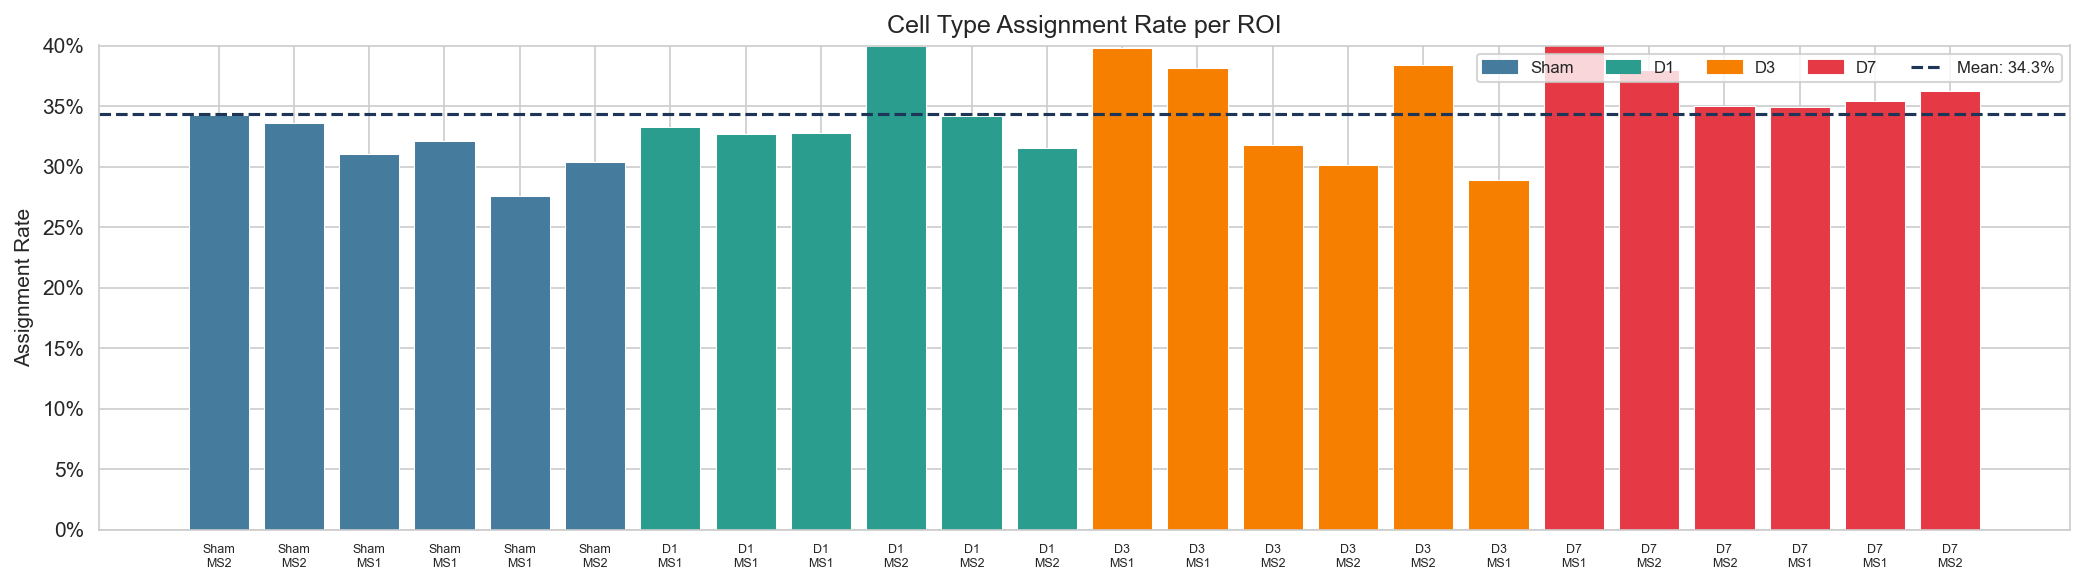

Assignment rate: 27.5% – 44.0% (mean 34.3%)


In [6]:
# --- 2a. Assignment rates by ROI ---
roi_sorted = roi_abundances.sort_values('timepoint')

fig, ax = plt.subplots(figsize=(14, 4))
colors = [TP_COLORS.get(tp, '#999') for tp in roi_sorted['timepoint']]
bars = ax.bar(range(len(roi_sorted)), roi_sorted['assignment_rate'], color=colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(roi_sorted['assignment_rate'].mean(), color='#1D3557', linestyle='--',
           linewidth=1.5, label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}')
ax.set_xticks(range(len(roi_sorted)))
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in roi_sorted.iterrows()],
                    fontsize=6, rotation=0)
ax.set_ylabel('Assignment Rate')
ax.set_title('Cell Type Assignment Rate per ROI')
ax.set_ylim(0, 0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
handles.append(plt.Line2D([0], [0], color='#1D3557', linestyle='--',
               label=f'Mean: {roi_sorted["assignment_rate"].mean():.1%}'))
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

print(f'Assignment rate: {roi_sorted["assignment_rate"].min():.1%} \u2013 '
      f'{roi_sorted["assignment_rate"].max():.1%} '
      f'(mean {roi_sorted["assignment_rate"].mean():.1%})')

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1692925960.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


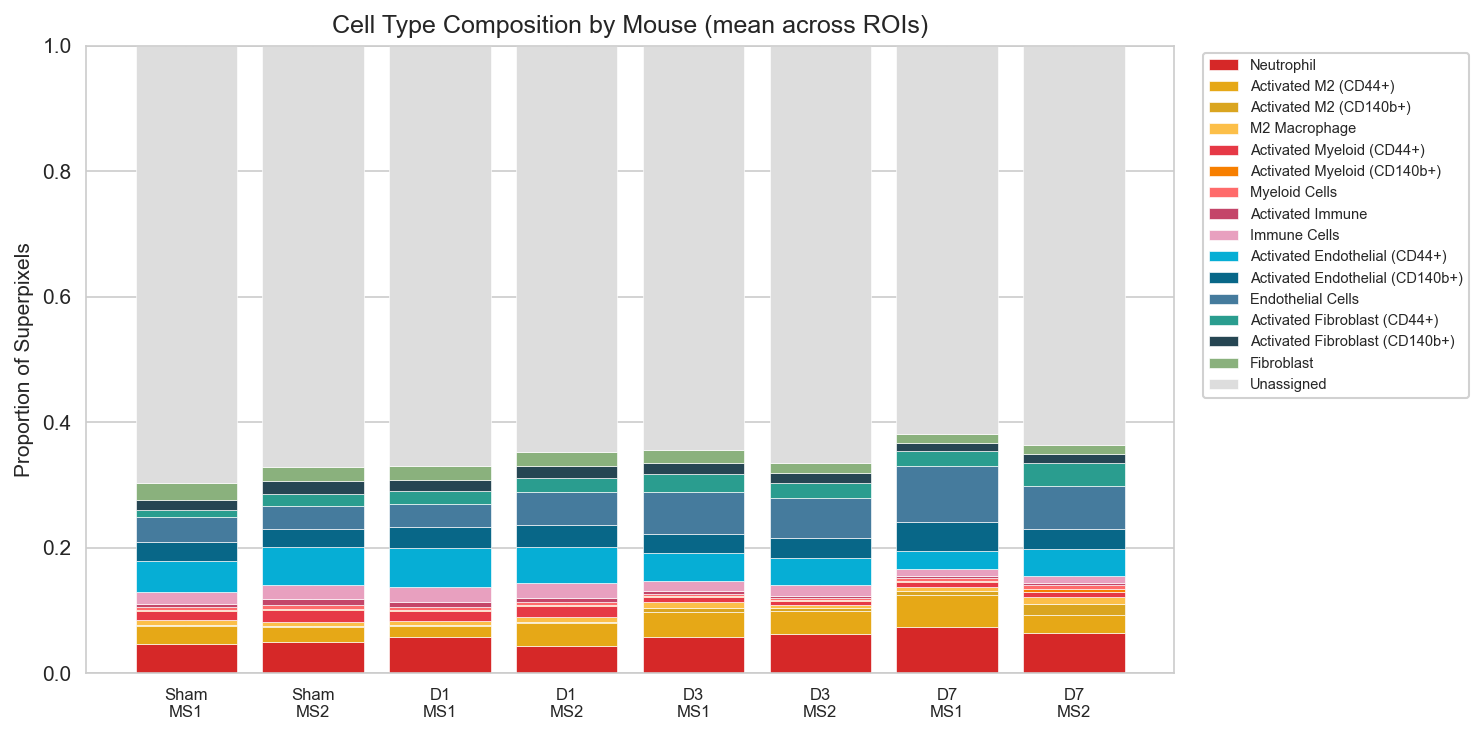

In [7]:
# --- 2b. Cell type composition at mouse level ---
prop_cols = [f'{ct}_prop' for ct in CT_ORDER]
existing_prop_cols = [c for c in prop_cols if c in roi_abundances.columns]
existing_cts = [c.replace('_prop', '') for c in existing_prop_cols]

mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
mouse_agg = mouse_agg.sort_values(['timepoint', 'mouse'])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(mouse_agg))
bottom = np.zeros(len(mouse_agg))

for ct, col in zip(existing_cts, existing_prop_cols):
    vals = mouse_agg[col].values
    ax.bar(x, vals, bottom=bottom, color=CT_COLORS.get(ct, '#999'),
           label=ct_label(ct), edgecolor='white', linewidth=0.3)
    bottom += vals

# Unassigned on top
unassigned = 1.0 - bottom
ax.bar(x, np.maximum(unassigned, 0), bottom=bottom, color='#DDDDDD',
       label='Unassigned', edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['timepoint']}\n{r['mouse']}" for _, r in mouse_agg.iterrows()],
                    fontsize=8)
ax.set_ylabel('Proportion of Superpixels')
ax.set_title('Cell Type Composition by Mouse (mean across ROIs)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, framealpha=0.9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1519973823.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()


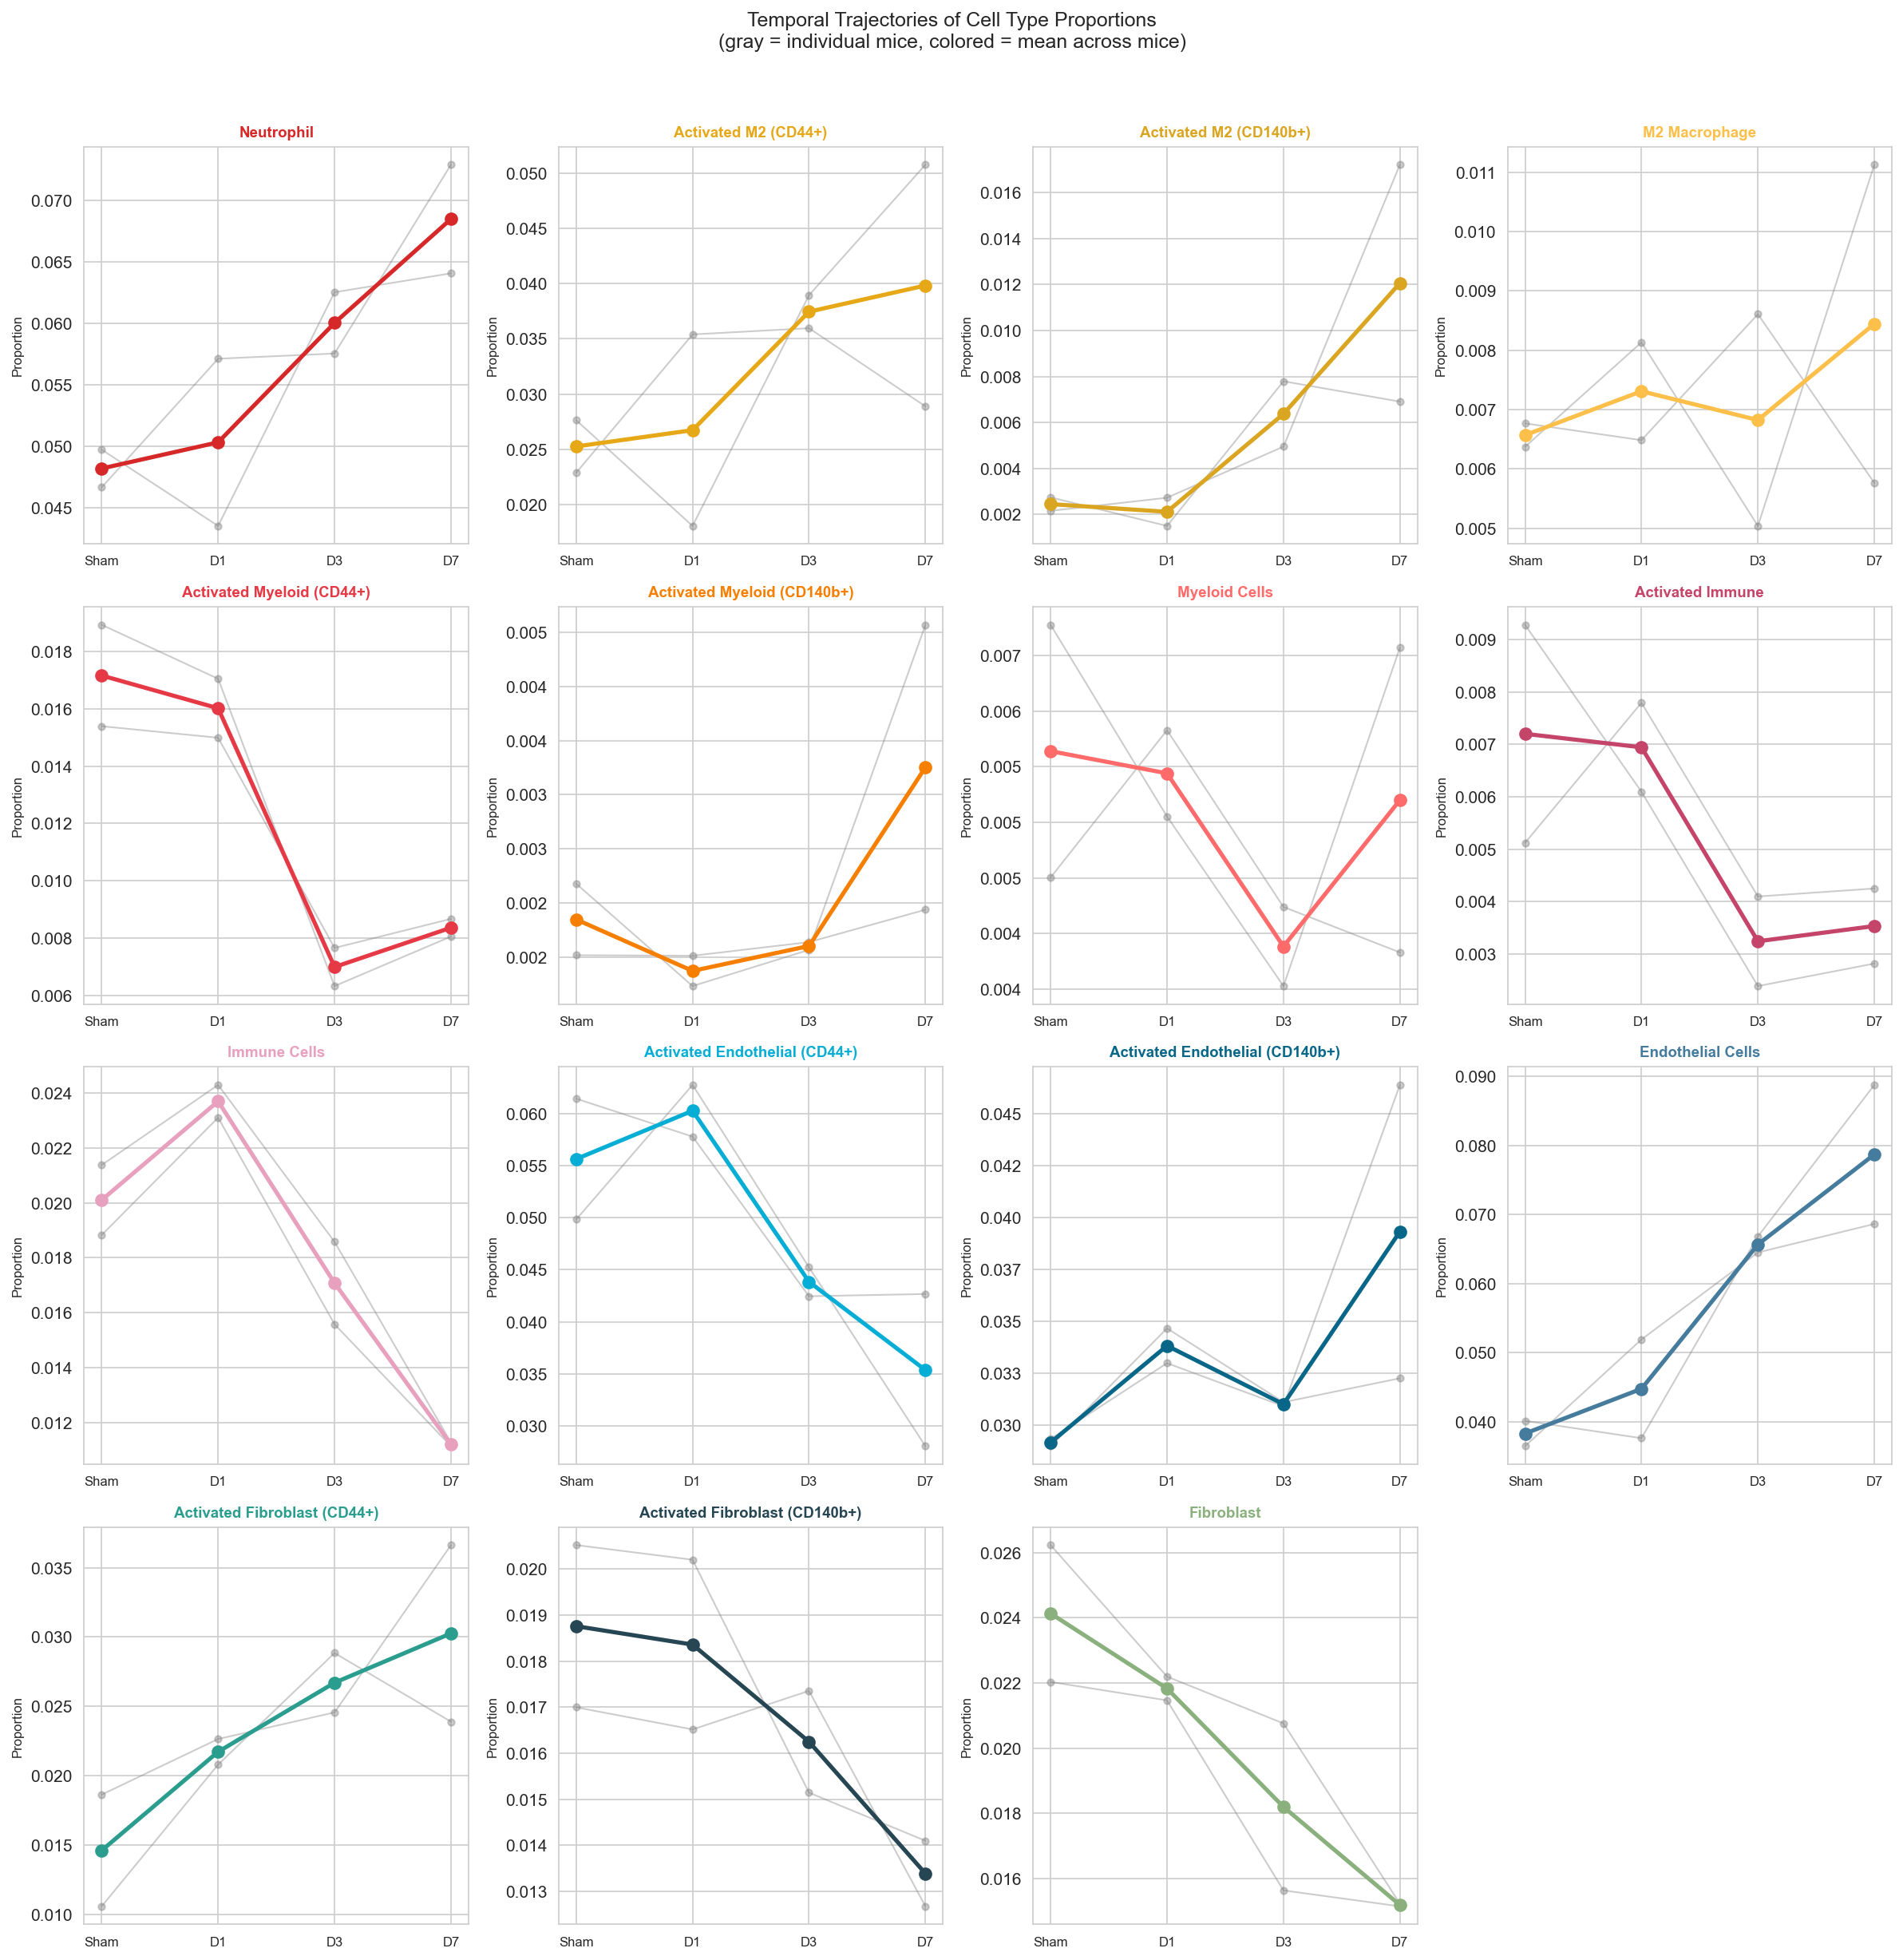

In [8]:
# --- 2c. Temporal trajectories per cell type ---
mouse_agg_tp = roi_abundances.groupby(['timepoint', 'mouse'])[existing_prop_cols].mean().reset_index()
mouse_agg_tp['timepoint'] = pd.Categorical(mouse_agg_tp['timepoint'], categories=TP_ORDER, ordered=True)

n_cts = len(existing_cts)
ncols = 4
nrows = (n_cts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, (ct, col) in enumerate(zip(existing_cts, existing_prop_cols)):
    ax = axes[i]
    tp_means = mouse_agg_tp.groupby('timepoint', observed=True)[col].mean()

    # Individual mice as thin lines
    for mouse, grp in mouse_agg_tp.groupby('mouse'):
        grp_sorted = grp.sort_values('timepoint')
        tp_idx = [TP_ORDER.index(tp) for tp in grp_sorted['timepoint']]
        ax.plot(tp_idx, grp_sorted[col].values, 'o-', color='gray',
                alpha=0.4, linewidth=1, markersize=4)

    # Mean line
    mean_vals = [tp_means.get(tp, np.nan) for tp in TP_ORDER]
    ax.plot(range(len(TP_ORDER)), mean_vals, 'o-',
            color=CT_COLORS.get(ct, '#1D3557'), linewidth=2.5, markersize=7, zorder=5)

    ax.set_xticks(range(len(TP_ORDER)))
    ax.set_xticklabels(TP_ORDER, fontsize=8)
    ax.set_title(ct_label(ct), fontsize=9, fontweight='bold',
                 color=CT_COLORS.get(ct, '#333'))
    ax.set_ylabel('Proportion', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.3f}'))

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Temporal Trajectories of Cell Type Proportions\n'
             '(gray = individual mice, colored = mean across mice)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Continuous Lineage Composition

Discrete gates label ~24% of the tissue. What about the other ~76%?

The continuous system scores every superpixel on three independent axes (immune, endothelial, stromal), sigmoid-normalized within each ROI. A superpixel with high immune *and* high stromal signal — a likely site of leukocyte-fibroblast interaction — shows up as multi-lineage rather than forced into one discrete bucket with rival votes discarded. Panel A below shows mean lineage score per timepoint. Panel B shows the `mixed_fraction` — the proportion of tissue scoring on 2+ lineages simultaneously.

**Normalization note.** Lineage sigmoids are now centered on a Sham-pooled per-mouse reference and scaled by the experiment-wide IQR (Phase 1 seam closure), so inter-timepoint shifts are preserved at the cohort level rather than compressed by per-ROI self-normalization. §3d reports Hedges' g on the lineage scores directly; §6 then tests the same signal under a second, independent path (raw-marker Sham-reference percentile) and reports their magnitude disagreement explicitly.

/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1230582462.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[lineage_cols].mean().reset_index()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1230582462.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_mean = mouse_agg.groupby('timepoint')[lineage_cols].mean()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1230582462.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

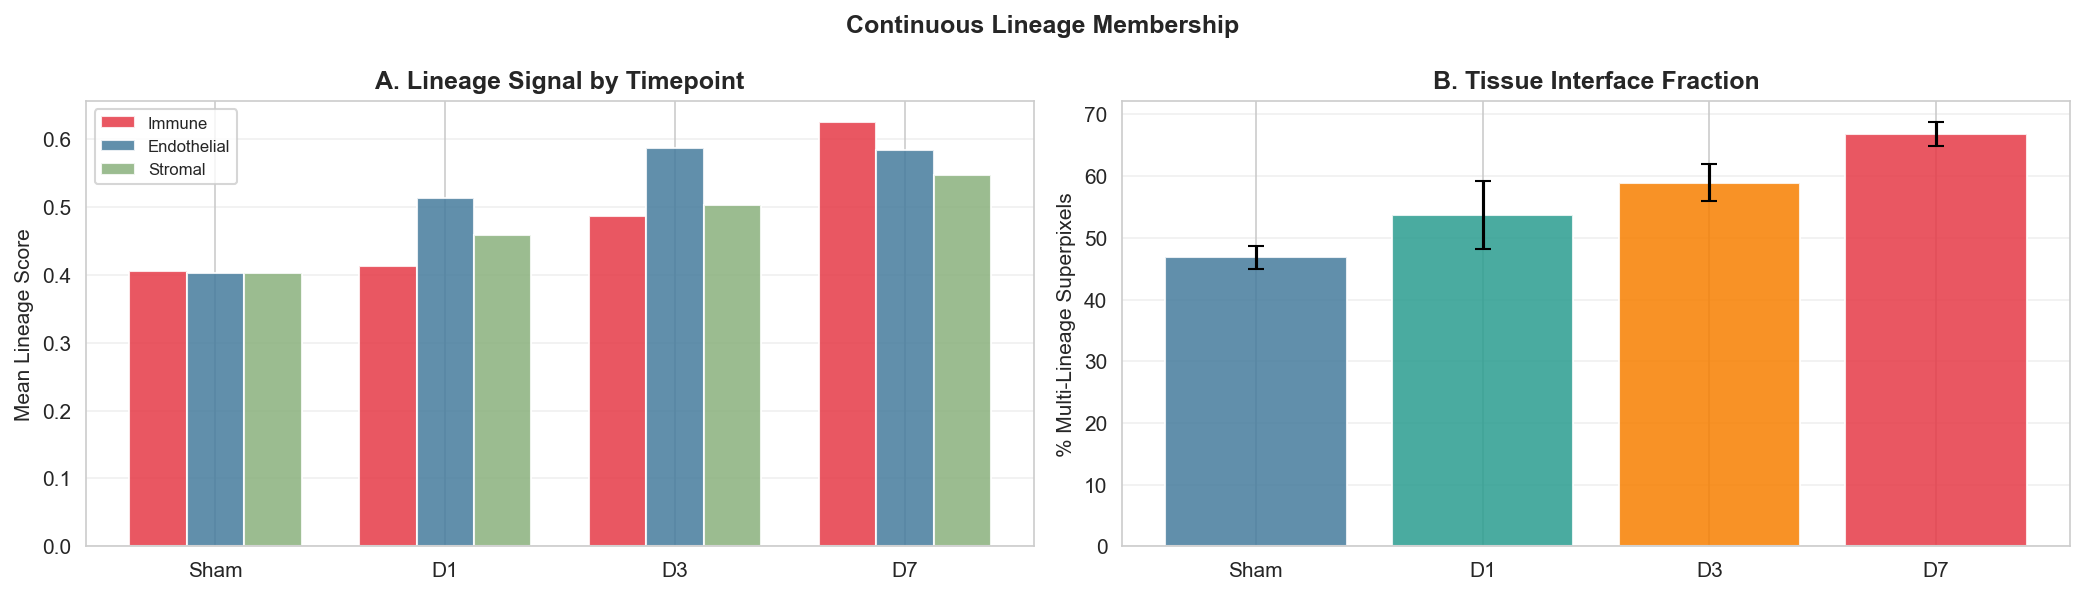

In [9]:
# --- 2d. Lineage composition and interface fraction ---
lineage_cols = [c for c in roi_abundances.columns if c.startswith('lineage_') and c.endswith('_mean')]

if lineage_cols and 'mixed_fraction' in roi_abundances.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Panel A: Mean lineage scores by timepoint
    mouse_agg = roi_abundances.groupby(['timepoint', 'mouse'])[lineage_cols].mean().reset_index()
    mouse_agg['timepoint'] = pd.Categorical(mouse_agg['timepoint'], categories=TP_ORDER, ordered=True)
    mouse_mean = mouse_agg.groupby('timepoint')[lineage_cols].mean()
    
    x = np.arange(len(mouse_mean))
    width = 0.25
    lineage_colors = {'lineage_immune_mean': '#E63946', 'lineage_endothelial_mean': '#457B9D', 'lineage_stromal_mean': '#8AB17D'}
    
    for i, col in enumerate(lineage_cols):
        label = col.replace('lineage_', '').replace('_mean', '').capitalize()
        color = lineage_colors.get(col, f'C{i}')
        ax1.bar(x + i * width - width, mouse_mean[col].values, width,
                label=label, color=color, alpha=0.85, edgecolor='white')
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(mouse_mean.index, fontsize=10)
    ax1.set_ylabel('Mean Lineage Score')
    ax1.set_title('A. Lineage Signal by Timepoint', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel B: Multi-lineage fraction trend
    mouse_mixed = roi_abundances.groupby(['timepoint', 'mouse'])['mixed_fraction'].mean().reset_index()
    mouse_mixed['timepoint'] = pd.Categorical(mouse_mixed['timepoint'], categories=TP_ORDER, ordered=True)
    
    for tp_idx, tp in enumerate(TP_ORDER):
        vals = mouse_mixed[mouse_mixed['timepoint'] == tp]['mixed_fraction'] * 100
        color = TP_COLORS.get(tp, '#999')
        ax2.bar(tp_idx, vals.mean(), yerr=vals.std() if len(vals) > 1 else 0,
                color=color, capsize=4, alpha=0.85, edgecolor='white')
    
    ax2.set_xticks(range(len(TP_ORDER)))
    ax2.set_xticklabels(TP_ORDER, fontsize=10)
    ax2.set_ylabel('% Multi-Lineage Superpixels')
    ax2.set_title('B. Tissue Interface Fraction', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    fig.suptitle('Continuous Lineage Membership', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print("Lineage columns not found in roi_abundances — re-run differential_abundance_analysis.py")

---
## 3. Differential Abundance: The 15 Config-Defined Cell Types (Layer A)

§1-§2 mapped the tissue; this section asks which of the **15 cell types defined in `config.json`** change across timepoints. Each cell type is defined by a boolean-gating rule (positive AND negative markers) — for example, `neutrophil = CD45+ AND Ly6G+ AND CD31− AND CD34−`. Mouse-level proportions are tested pairwise across timepoints with Hedges' g effect sizes and bootstrap ranges.

**What this section shows.** Which of the 15 cell types rise or fall across Sham → D1 → D3 → D7; cortex-vs-medulla comparisons; a separate lineage rollup view (§3D) that aggregates cell types by lineage family.

**What it does not show.** Spatial reorganization (§4), continuous lineage score shifts (§6), or whether observed changes are normalization artifacts.

**n=2 realities.** Mann-Whitney U at n=2 produces only three p-values (~0.33, 0.67, 1.0) — no comparison can reach α=0.05 regardless of magnitude. Bootstrap ranges reflect ~9 unique resample values and are NOT coverage-bearing intervals. No FDR is claimed. The purpose is effect-size estimation for follow-up design.

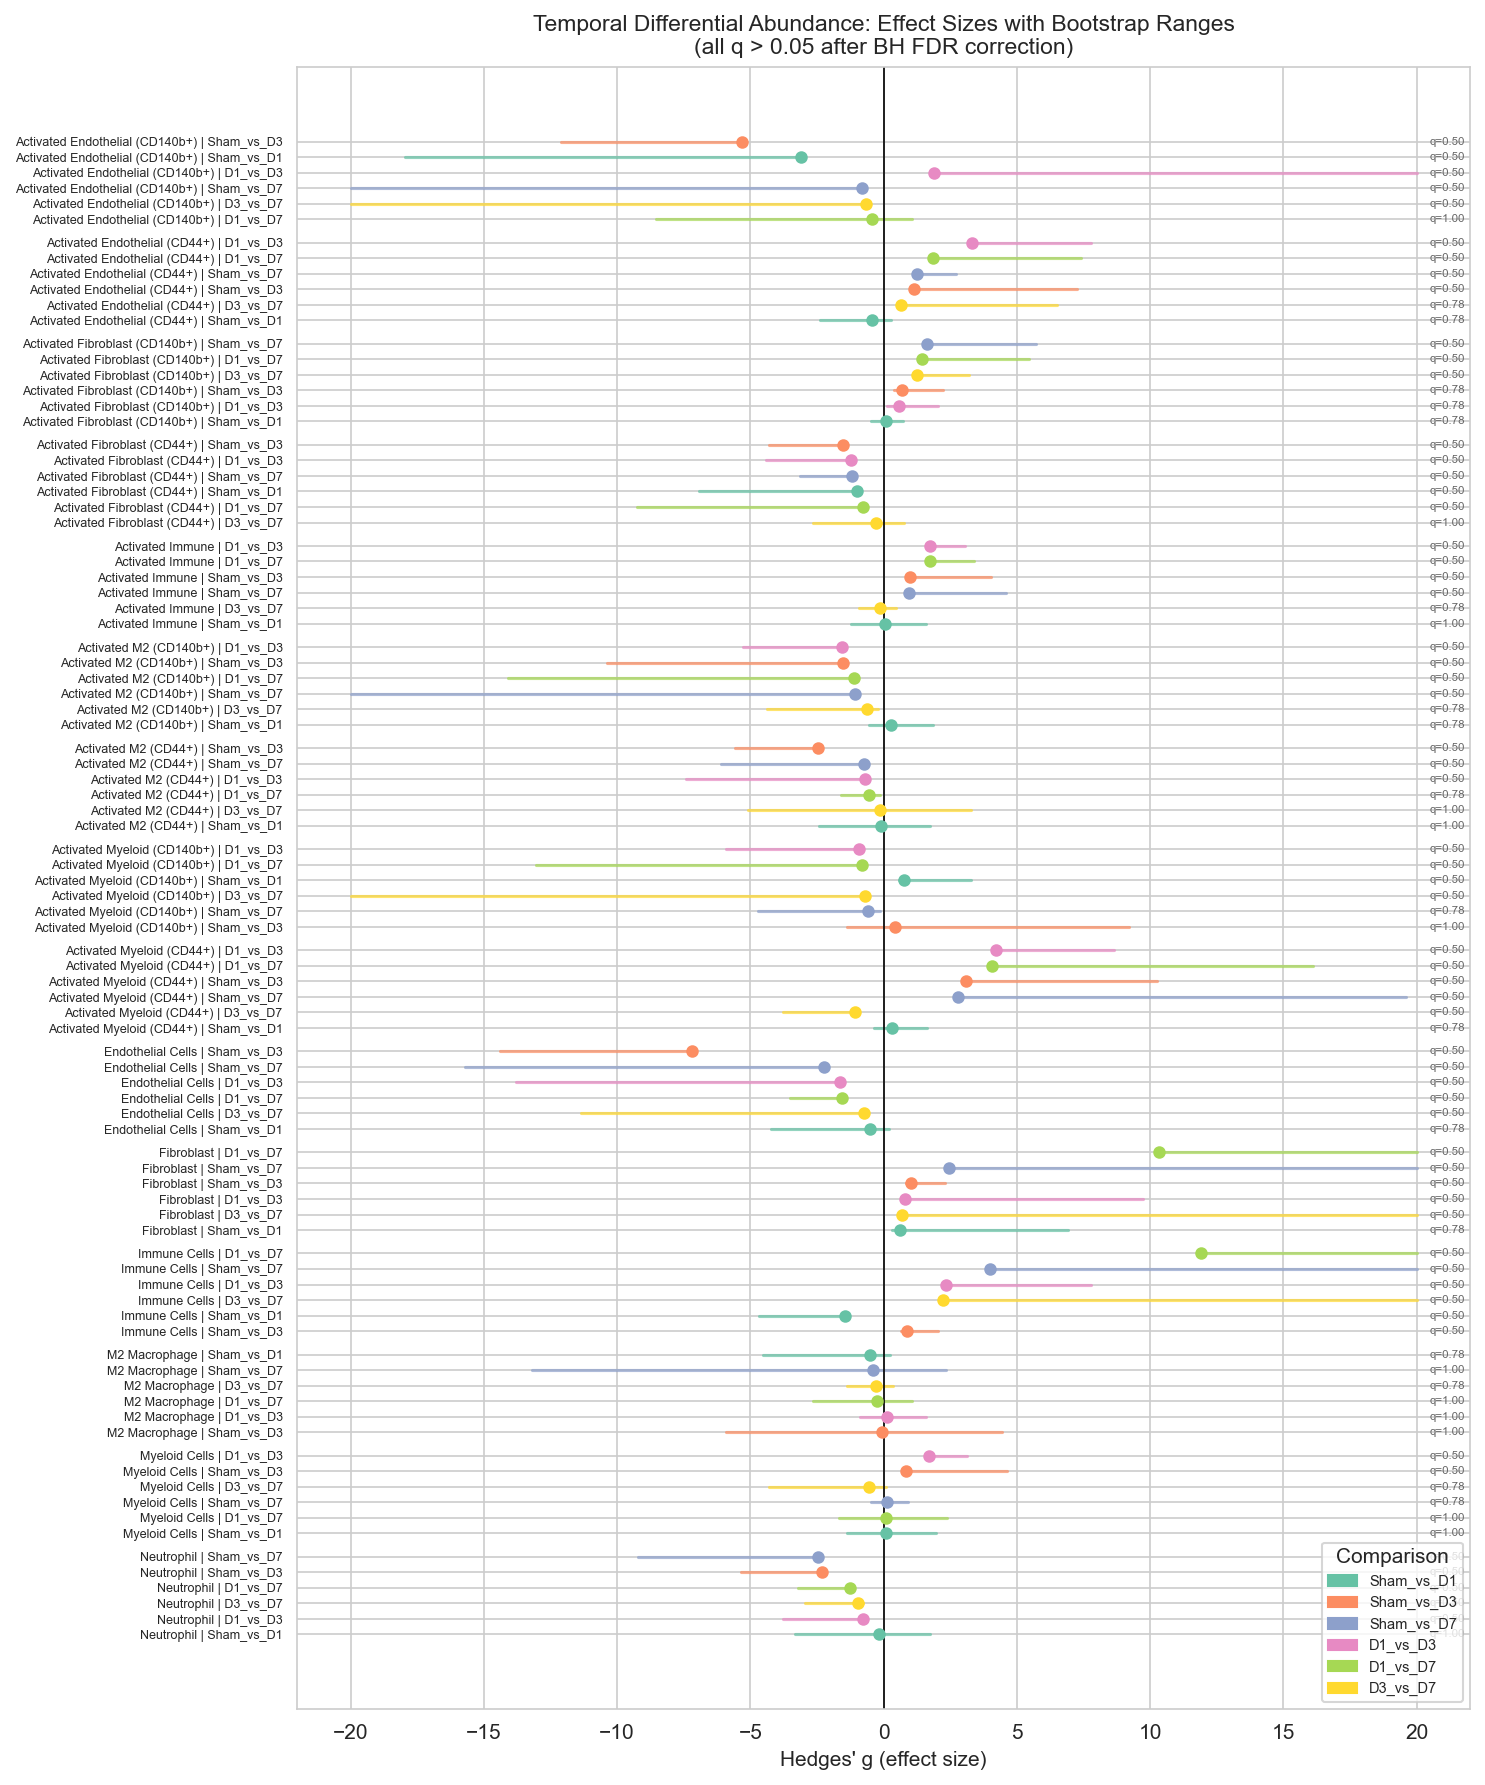

In [10]:
# --- 3A. Forest plot: Hedges' g for the 15 config cell types ---
comparisons = temporal_da['comparison'].unique()
comp_colors = dict(zip(comparisons, sns.color_palette('Set2', len(comparisons))))

# Sort: group by cell type, within each by |hedges_g|
temporal_da['abs_g'] = temporal_da['hedges_g'].abs()
plot_df = temporal_da.sort_values(['cell_type', 'abs_g'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(10, 12))
y_positions = []
y_labels = []
y = 0
prev_ct = None

for _, row in plot_df.iterrows():
    ct = row['cell_type']
    if ct != prev_ct and prev_ct is not None:
        y += 0.5  # gap between cell types
    prev_ct = ct

    color = comp_colors[row['comparison']]
    ci_lo = row['bootstrap_range_min'] if not np.isnan(row['bootstrap_range_min']) else row['hedges_g'] - 1
    ci_hi = row['bootstrap_range_max'] if not np.isnan(row['bootstrap_range_max']) else row['hedges_g'] + 1

    # Clip extreme CIs for readability
    ci_lo_plot = max(ci_lo, -20)
    ci_hi_plot = min(ci_hi, 20)

    ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
    ax.plot(row['hedges_g'], y, 'o', color=color, markersize=5, zorder=5)

    # q-value annotation
    q_text = f"q={row['p_value_fdr']:.2f}" if not np.isnan(row['p_value_fdr']) else 'q=NA'
    ax.text(20.5, y, q_text, fontsize=5.5, va='center', color='#666')

    y_positions.append(y)
    y_labels.append(f"{ct_label(ct)} | {row['comparison']}")
    y += 1

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel('Hedges\' g (effect size)', fontsize=10)
ax.set_title('Temporal Differential Abundance: Effect Sizes with Bootstrap Ranges\n'
             '(all q > 0.05 after BH FDR correction)', fontsize=11)
ax.set_xlim(-22, 22)
ax.invert_yaxis()

legend_handles = [mpatches.Patch(color=c, label=comp) for comp, c in comp_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7, title='Comparison')
plt.tight_layout()
plt.show()

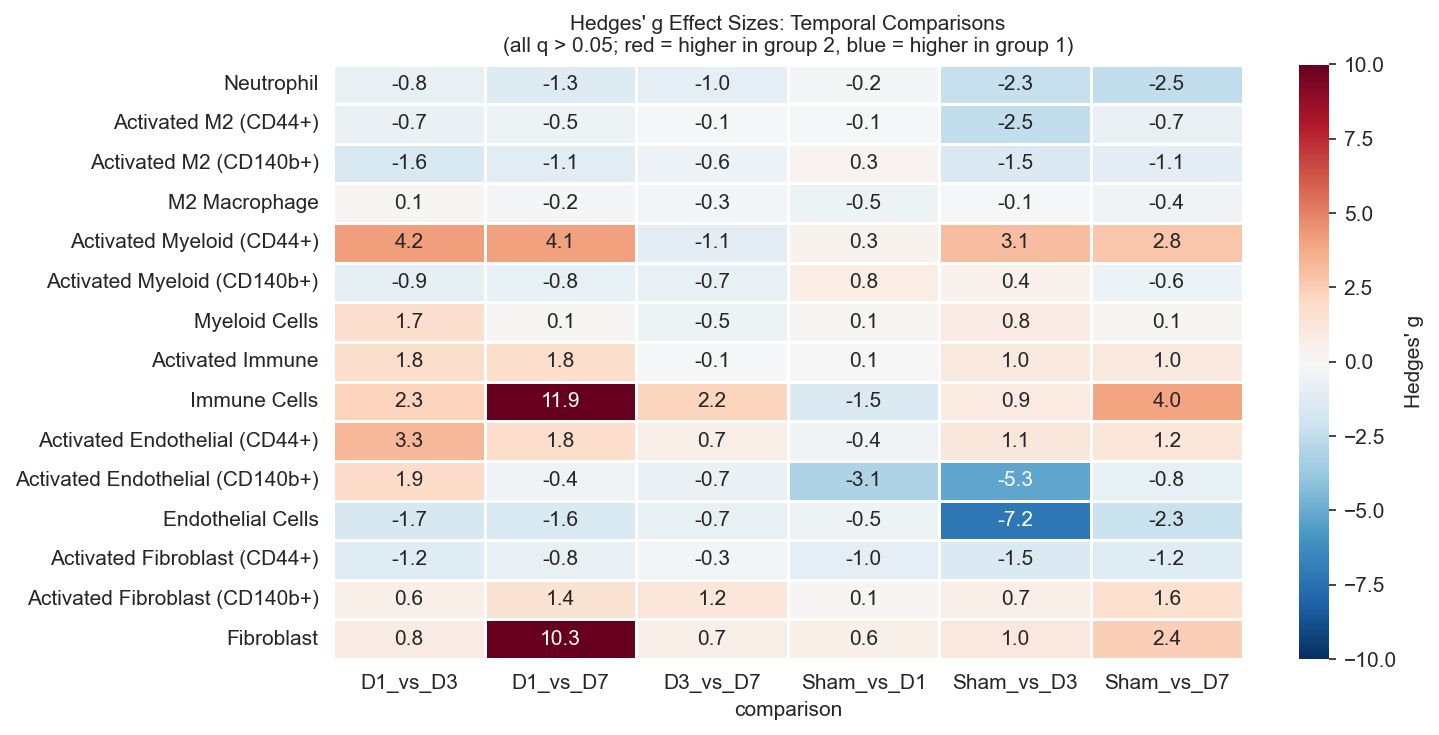

In [11]:
# --- 3B. Effect size heatmap across the 15 config cell types × 6 pairwise contrasts ---
pivot = temporal_da.pivot_table(index='cell_type', columns='comparison',
                                values='hedges_g', aggfunc='first')
# Reorder
pivot = pivot.reindex(index=[ct for ct in CT_ORDER if ct in pivot.index])
pivot_labels = pivot.rename(index=ct_label)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = min(abs(pivot.values[np.isfinite(pivot.values)]).max(), 10)
sns.heatmap(pivot_labels, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': "Hedges' g"}, ax=ax)
ax.set_title("Hedges' g Effect Sizes: Temporal Comparisons\n"
             "(all q > 0.05; red = higher in group 2, blue = higher in group 1)",
             fontsize=10)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

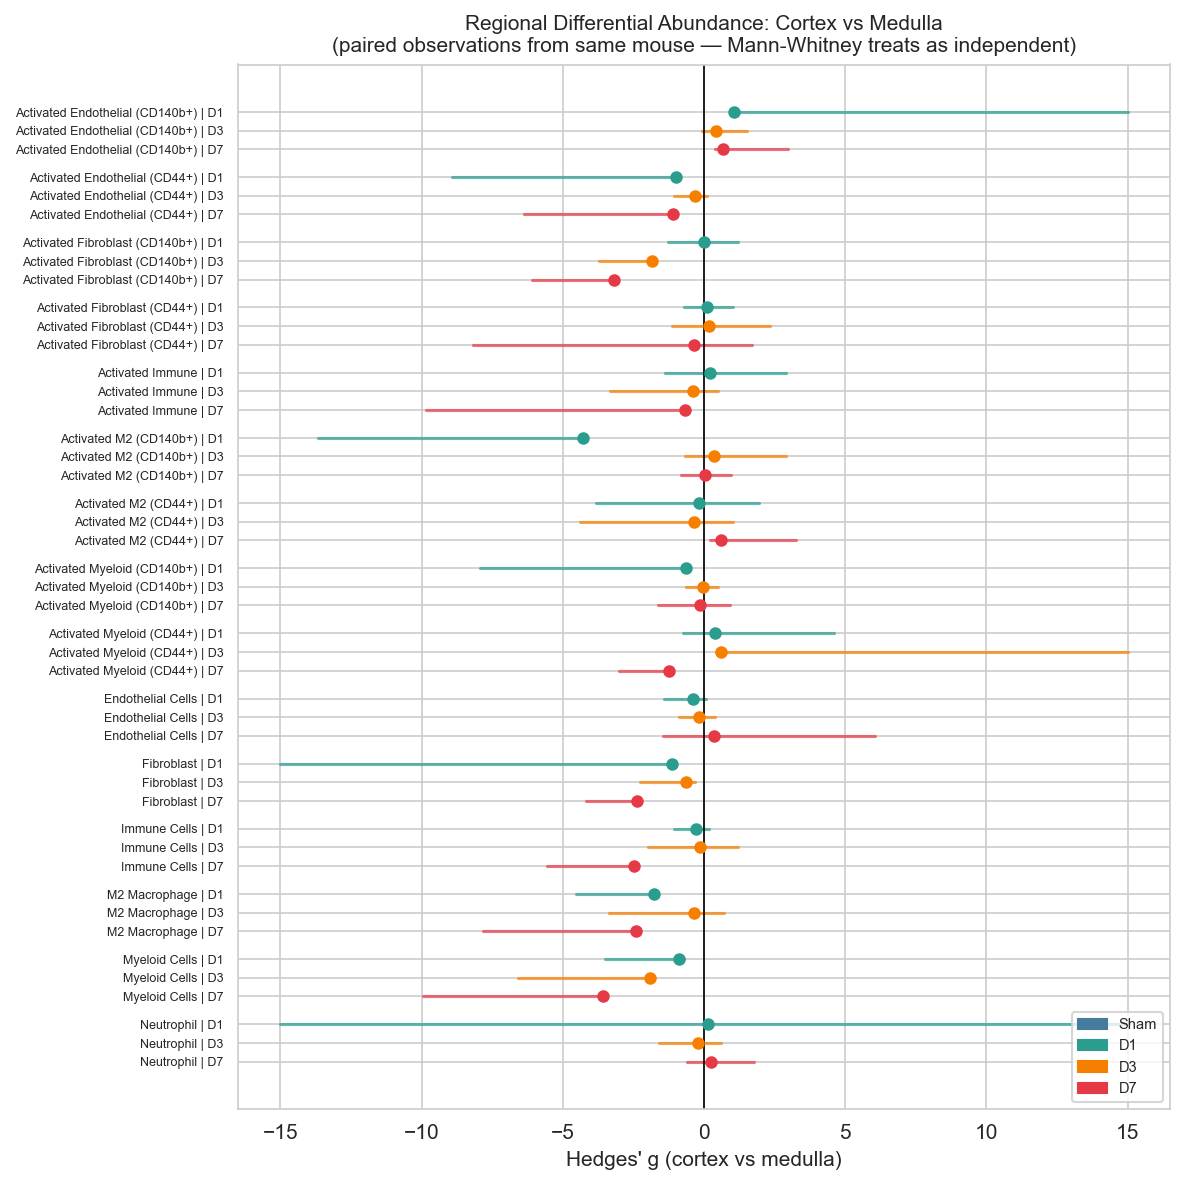

In [12]:
# --- 3C. Regional comparison (cortex vs medulla, Layer A cell types) ---
if len(regional_da) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    regional_da_sorted = regional_da.sort_values(['cell_type', 'timepoint'])

    y = 0
    y_positions = []
    y_labels = []
    prev_ct = None

    for _, row in regional_da_sorted.iterrows():
        ct = row['cell_type']
        if ct != prev_ct and prev_ct is not None:
            y += 0.5
        prev_ct = ct

        tp = row['timepoint']
        color = TP_COLORS.get(tp, '#999')
        g = row['hedges_g']
        ci_lo = row.get('bootstrap_range_min', g - 1)
        ci_hi = row.get('bootstrap_range_max', g + 1)
        if pd.isna(ci_lo): ci_lo = g - 1
        if pd.isna(ci_hi): ci_hi = g + 1

        ci_lo_plot = max(ci_lo, -15)
        ci_hi_plot = min(ci_hi, 15)

        ax.plot([ci_lo_plot, ci_hi_plot], [y, y], color=color, linewidth=1.5, alpha=0.7)
        ax.plot(g, y, 'o', color=color, markersize=5, zorder=5)

        y_positions.append(y)
        y_labels.append(f'{ct_label(ct)} | {tp}')
        y += 1

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel("Hedges' g (cortex vs medulla)", fontsize=10)
    ax.set_title('Regional Differential Abundance: Cortex vs Medulla\n'
                 '(paired observations from same mouse \u2014 Mann-Whitney treats as independent)',
                 fontsize=10)
    ax.invert_yaxis()

    handles = [mpatches.Patch(color=c, label=tp) for tp, c in TP_COLORS.items()]
    ax.legend(handles=handles, loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('No regional DA results available.')

In [13]:
# --- 3D. Lineage + subtype rollups (Layer B) ---
# Aggregated view: each of the 15 config cell types rolls up into one of three lineage
# families (immune / endothelial / stromal) and — within immune — into one of four subtypes.
# Computed from the SAME ROI proportions as §3A, just aggregated. Effect sizes here are
# attenuated relative to specific cell types because aggregation averages across activation
# states.

if len(temporal_rollups) > 0:
    # Continuous lineage scores (3 axes, Sham-reference-centered sigmoid since Phase 1)
    lineage_rows = temporal_rollups[temporal_rollups['cell_type'].str.startswith('lineage:')]
    if len(lineage_rows) > 0:
        print('Lineage-level rollups (3 axes, continuous score mean per ROI):')
        print('=' * 80)
        disp = lineage_rows.sort_values('hedges_g', key=abs, ascending=False)[
            ['cell_type', 'comparison', 'mean_1', 'mean_2', 'hedges_g', 'p_value_fdr']
        ].copy()
        disp.columns = ['lineage', 'contrast', 'mean_tp1', 'mean_tp2', 'hedges_g', 'q']
        with pd.option_context('display.float_format', '{:.3f}'.format):
            print(disp.to_string(index=False))
        print()
        print('Phase 1 replaced per-ROI sigmoid with Sham-reference-centered sigmoid (commit 51f120d);')
        print('continuous lineage means now reflect Sham-pooled per-mouse 60th-percentile centering with')
        print('experiment-wide IQR scale. Phase 2 (§6) operates on these scores and cross-checks them')
        print()

    # Subtype rollups (within-immune refinement)
    subtype_rows = temporal_rollups[temporal_rollups['cell_type'].str.startswith('subtype_')]
    if len(subtype_rows) > 0:
        print('Subtype-level rollups (within immune lineage):')
        print('=' * 80)
        disp = subtype_rows.sort_values('hedges_g', key=abs, ascending=False)[
            ['cell_type', 'comparison', 'mean_1', 'mean_2', 'hedges_g', 'p_value_fdr']
        ].copy()
        disp.columns = ['subtype', 'contrast', 'prop_tp1', 'prop_tp2', 'hedges_g', 'q']
        with pd.option_context('display.float_format', '{:.3f}'.format):
            print(disp.to_string(index=False))
else:
    print('temporal_lineage_rollups.csv not found — re-run differential_abundance_analysis.py')

Lineage-level rollups (3 axes, continuous score mean per ROI):
            lineage   contrast  mean_tp1  mean_tp2  hedges_g     q
    lineage:stromal Sham_vs_D7     0.402     0.547    -4.836 0.400
lineage:endothelial Sham_vs_D3     0.403     0.586    -2.906 0.400
lineage:endothelial Sham_vs_D7     0.403     0.583    -2.624 0.400
lineage:endothelial Sham_vs_D1     0.403     0.513    -2.433 0.400
     lineage:immune   D1_vs_D7     0.413     0.624    -2.122 0.400
     lineage:immune Sham_vs_D7     0.405     0.624    -2.013 0.400
    lineage:stromal Sham_vs_D3     0.402     0.502    -1.922 0.400
     lineage:immune   D1_vs_D3     0.413     0.486    -1.844 0.400
     lineage:immune   D3_vs_D7     0.486     0.624    -1.508 0.400
     lineage:immune Sham_vs_D3     0.405     0.486    -1.369 0.400
    lineage:stromal   D1_vs_D7     0.459     0.547    -1.341 0.400
lineage:endothelial   D1_vs_D3     0.513     0.586    -1.007 0.400
lineage:endothelial   D1_vs_D7     0.513     0.583    -0.906 0.400

---
## 4. Spatial Neighborhood Architecture

Who sits next to whom. For each focal cell type in each ROI, we examine the 10 nearest neighboring superpixels and count what types they are, comparing to a permutation null (1,000 global shuffles of cell type labels within the ROI; Phipson-Smyth pseudocount). Enrichment ratios > 1 mean "this pair co-locates more than chance"; < 1 means avoidance.

**Self-enrichment caveat.** Cell types defined by overlapping markers (e.g., `activated_myeloid_cd44` and `activated_endothelial_cd44` both require CD44⁺) share expression space, and therefore physical space. Diagonal self-enrichment conflates genuine spatial clustering with marker-sharing circularity. Cross-type (off-diagonal) associations are more interpretable.

**What this section shows.** Which cell-type pairs co-localize, how those associations shift across timepoints, and cortex-vs-medulla differences in neighborhood structure.

**What it does not show.** Continuous-lineage neighborhood dynamics — those live in Family B (kidney notebook Part 2.5). Nor does co-localization imply functional interaction; it is spatial coincidence.

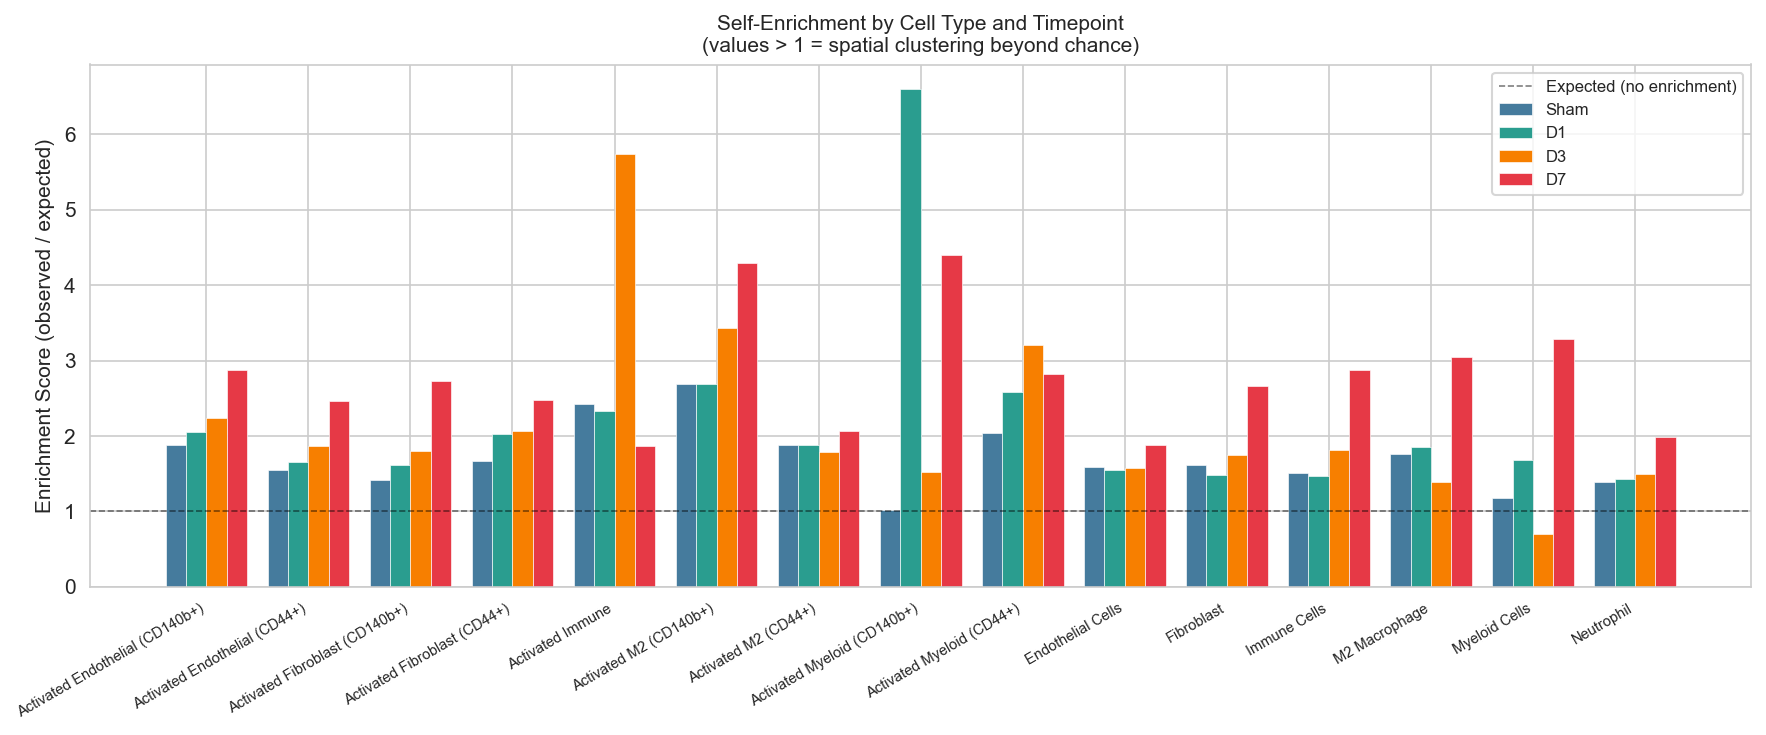

Self-enrichment range: 0.70x – 6.60x (all cell types cluster with themselves)


In [14]:
# --- 4a. Self-enrichment temporal dynamics ---
self_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] == temporal_enrich['neighbor_cell_type']
].copy()
self_enrich['timepoint'] = pd.Categorical(self_enrich['timepoint'],
                                          categories=TP_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 5))
ct_list = sorted(self_enrich['focal_cell_type'].unique())
x = np.arange(len(ct_list))
width = 0.2

for i, tp in enumerate(TP_ORDER):
    tp_data = self_enrich[self_enrich['timepoint'] == tp]
    vals = [tp_data[tp_data['focal_cell_type'] == ct]['enrichment_score'].values[0]
            if len(tp_data[tp_data['focal_cell_type'] == ct]) > 0 else 0
            for ct in ct_list]
    bars = ax.bar(x + i * width, vals, width, color=TP_COLORS[tp],
                  label=tp, edgecolor='white', linewidth=0.3)

ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
           label='Expected (no enrichment)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([ct_label(ct) for ct in ct_list], fontsize=7, rotation=30, ha='right')
ax.set_ylabel('Enrichment Score (observed / expected)')
ax.set_title('Self-Enrichment by Cell Type and Timepoint\n'
             '(values > 1 = spatial clustering beyond chance)', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Self-enrichment range: {self_enrich["enrichment_score"].min():.2f}x \u2013 '
      f'{self_enrich["enrichment_score"].max():.2f}x '
      f'(all cell types cluster with themselves)')

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/vp/rd7xppxs0tx1msdtwy779hk40000gn/T/ipykernel_46158/1770094215.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


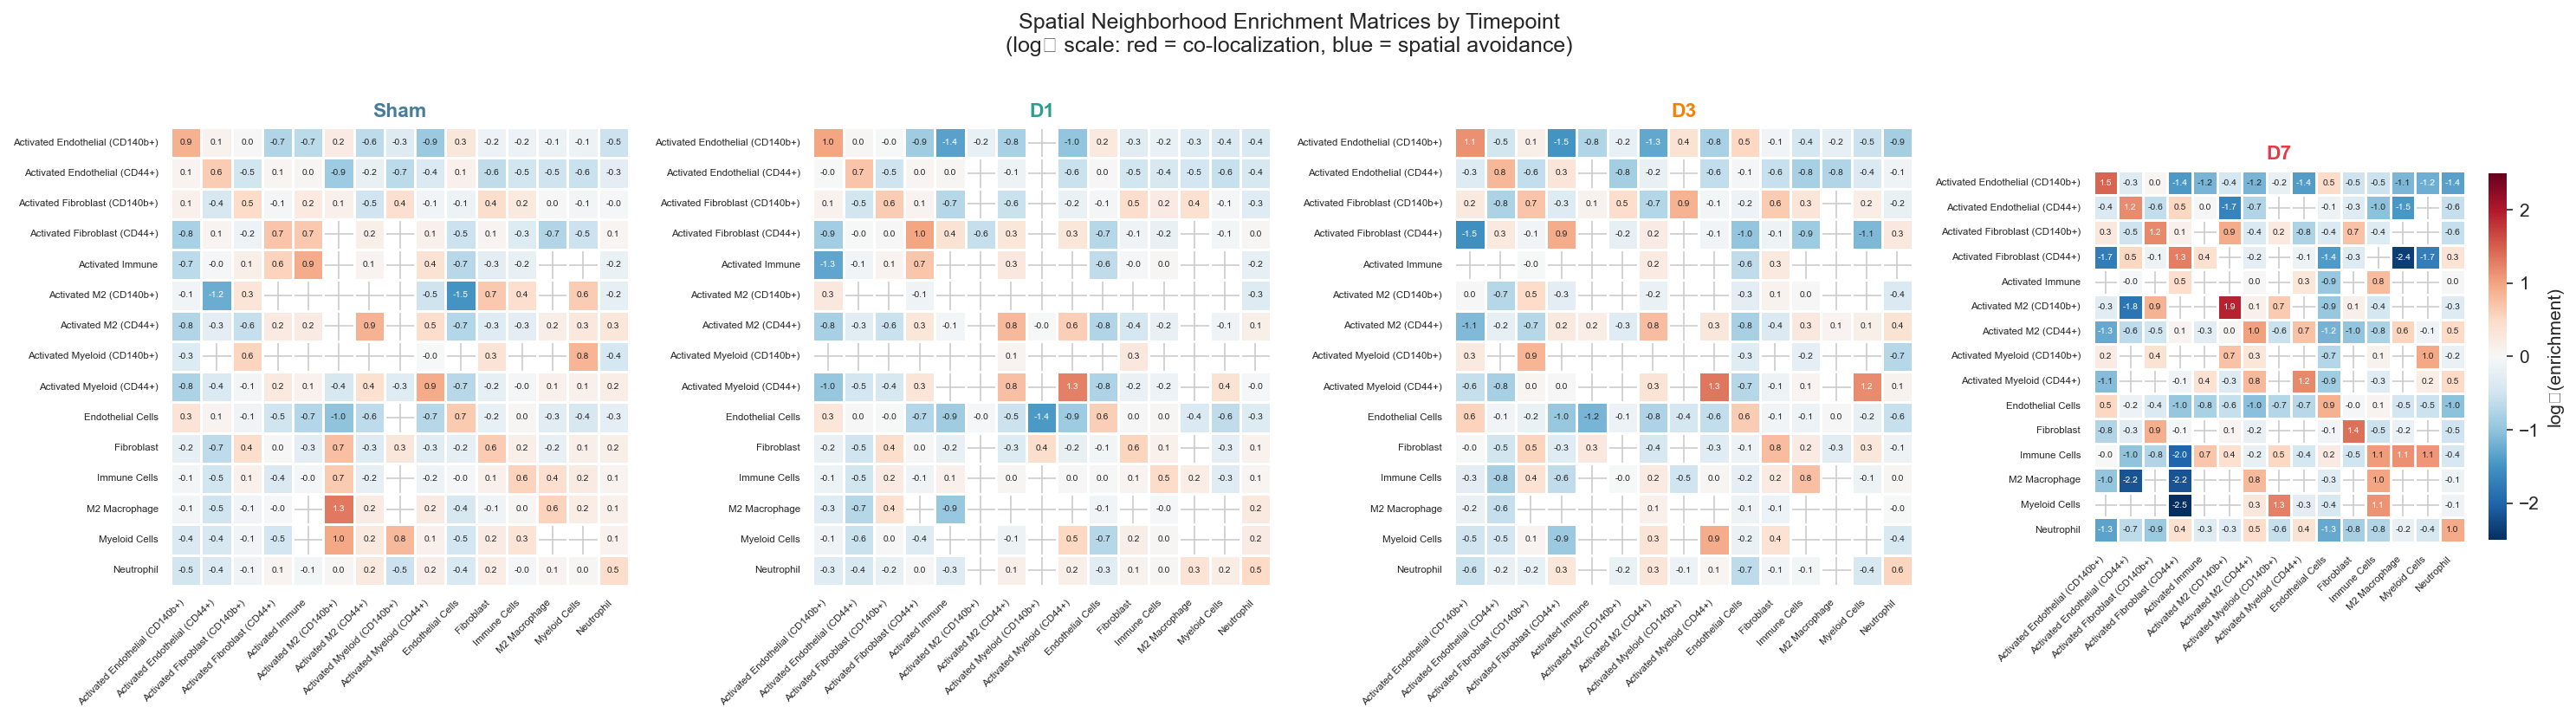

In [15]:
# --- 4b. Full enrichment matrices by timepoint ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_cts = sorted(temporal_enrich['focal_cell_type'].unique())
ct_short = [ct_label(ct) for ct in all_cts]

for idx, tp in enumerate(TP_ORDER):
    ax = axes[idx]
    tp_data = temporal_enrich[temporal_enrich['timepoint'] == tp]

    matrix = pd.DataFrame(np.nan, index=all_cts, columns=all_cts)
    for _, row in tp_data.iterrows():
        matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']

    matrix_display = matrix.copy()
    matrix_display.index = ct_short
    matrix_display.columns = ct_short

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == 3,
                cbar_kws={'label': 'log\u2082(enrichment)', 'shrink': 0.8} if idx == 3 else {},
                ax=ax, annot_kws={'fontsize': 5})
    ax.set_title(tp, fontsize=11, fontweight='bold', color=TP_COLORS[tp])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=5.5, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=5.5)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment Matrices by Timepoint\n'
             '(log\u2082 scale: red = co-localization, blue = spatial avoidance)',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

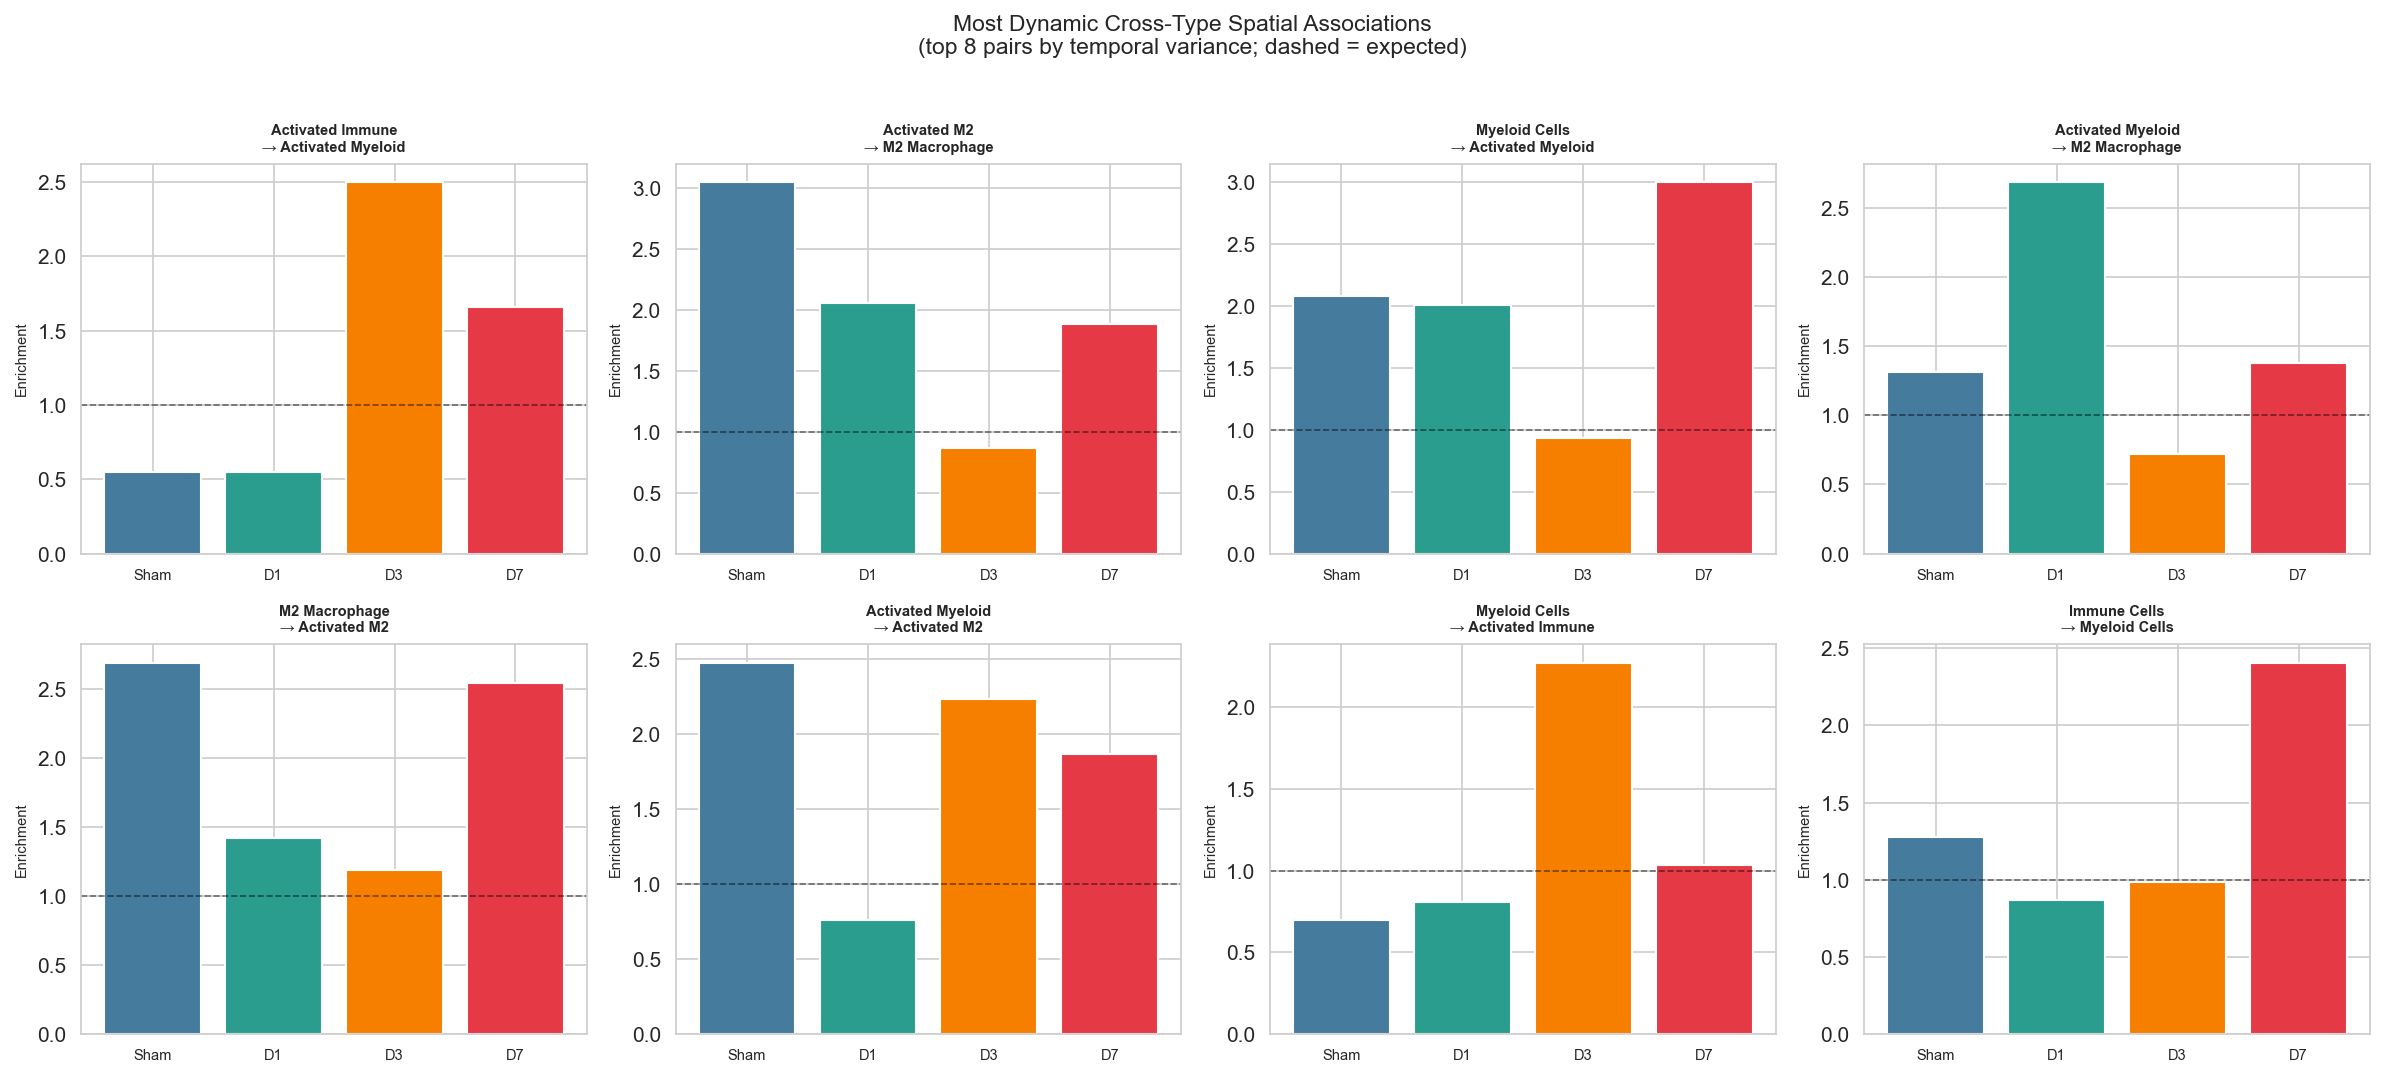

In [16]:
# --- 4c. Key temporal dynamics of cross-type pairs ---
cross_enrich = temporal_enrich[
    temporal_enrich['focal_cell_type'] != temporal_enrich['neighbor_cell_type']
].copy()

# Find most dynamic pairs (largest temporal variance)
pair_var = cross_enrich.groupby(
    ['focal_cell_type', 'neighbor_cell_type']
)['enrichment_score'].var().reset_index()
pair_var.columns = ['focal', 'neighbor', 'variance']
top_pairs = pair_var.nlargest(8, 'variance')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (_, pair) in enumerate(top_pairs.iterrows()):
    ax = axes[i]
    mask = ((cross_enrich['focal_cell_type'] == pair['focal']) &
            (cross_enrich['neighbor_cell_type'] == pair['neighbor']))
    pair_data = cross_enrich[mask].sort_values('timepoint')

    for _, row in pair_data.iterrows():
        tp = row['timepoint']
        ax.bar(TP_ORDER.index(tp), row['enrichment_score'],
               color=TP_COLORS.get(tp, '#999'), edgecolor='white')

    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(TP_ORDER, fontsize=7)
    focal_short = ct_label(pair['focal']).split('(')[0].strip()
    neighbor_short = ct_label(pair['neighbor']).split('(')[0].strip()
    ax.set_title(f'{focal_short}\n\u2192 {neighbor_short}',
                 fontsize=7, fontweight='bold')
    ax.set_ylabel('Enrichment', fontsize=7)

fig.suptitle('Most Dynamic Cross-Type Spatial Associations\n'
             '(top 8 pairs by temporal variance; dashed = expected)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/seaborn/utils.py:84: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/noot/Documents/IMC/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


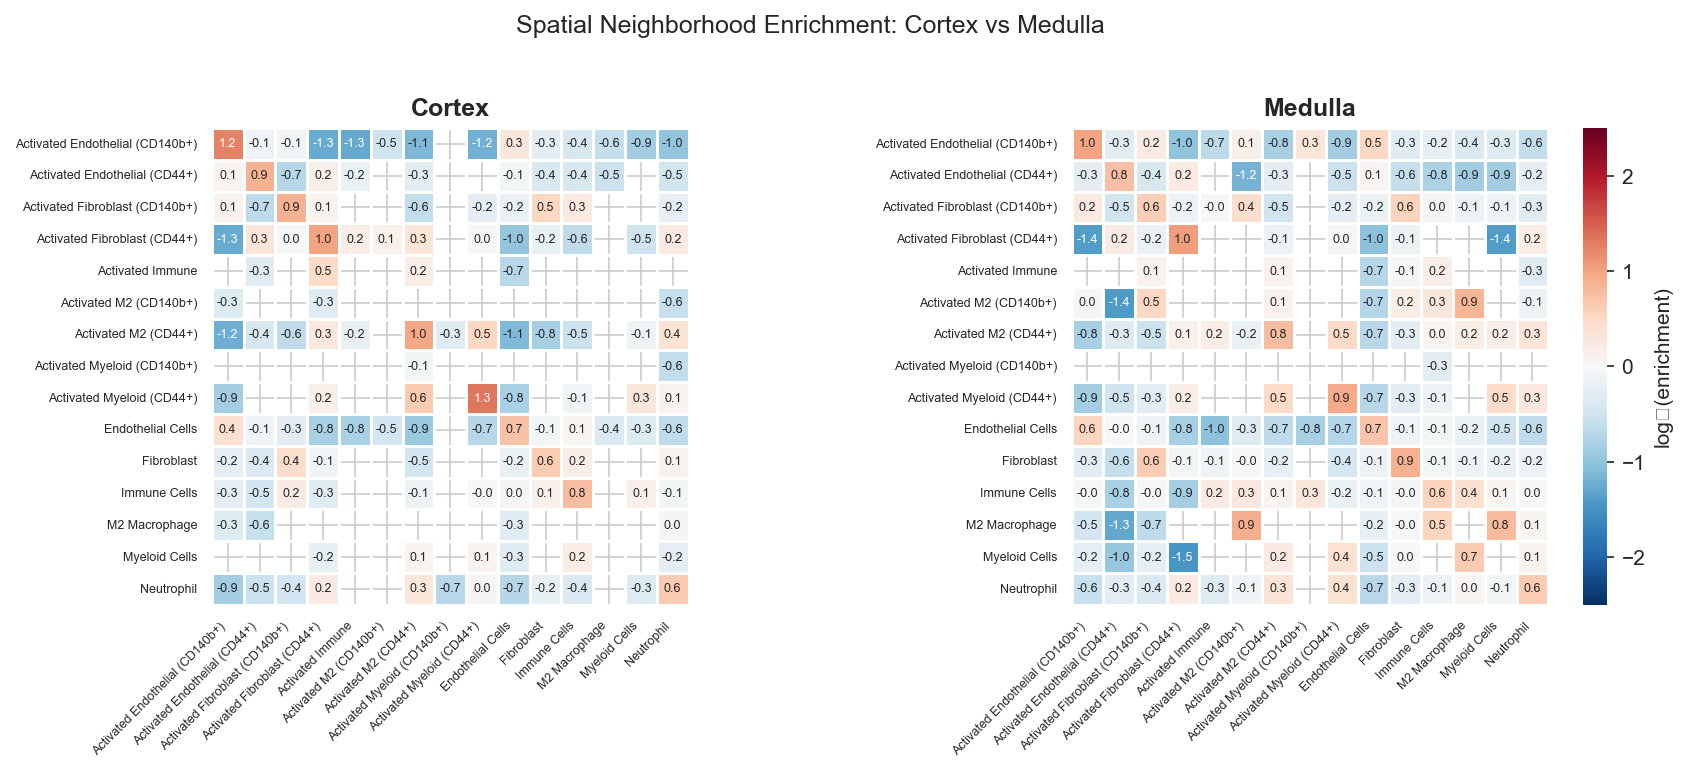

In [17]:
# --- 4d. Regional enrichment comparison ---
regions = sorted(regional_enrich['region'].unique())
all_cts_r = sorted(regional_enrich['focal_cell_type'].unique())
ct_short_r = [ct_label(ct) for ct in all_cts_r]

n_regions = len(regions)
fig, axes = plt.subplots(1, n_regions, figsize=(6 * n_regions, 5))
if n_regions == 1:
    axes = [axes]

for idx, region in enumerate(regions):
    ax = axes[idx]
    reg_data = regional_enrich[regional_enrich['region'] == region]

    matrix = pd.DataFrame(np.nan, index=all_cts_r, columns=all_cts_r)
    for _, row in reg_data.iterrows():
        if 'log2_enrichment' in row:
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = row['log2_enrichment']
        else:
            val = np.log2(row['enrichment_score']) if row['enrichment_score'] > 0 else np.nan
            matrix.loc[row['focal_cell_type'], row['neighbor_cell_type']] = val

    matrix_display = matrix.copy()
    matrix_display.index = ct_short_r
    matrix_display.columns = ct_short_r

    vmax = 2.5
    sns.heatmap(matrix_display, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5, linecolor='white',
                square=True, cbar=idx == n_regions - 1,
                cbar_kws={'label': 'log\u2082(enrichment)'} if idx == n_regions - 1 else {},
                ax=ax, annot_kws={'fontsize': 6})
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    if idx > 0:
        ax.set_ylabel('')

fig.suptitle('Spatial Neighborhood Enrichment: Cortex vs Medulla',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Knowledge Graph Context

Which interactions among the panel markers are already documented in the literature? We queried INDRA/CoGEx, a graph that aggregates ~35 million causal relationships mined from the biomedical literature, for two things: (a) which panel markers connect to each other mechanistically, and (b) which connect to acute kidney injury as a disease concept. 117 intra-panel edges span the 8 groundable genes (Ly6g, a murine-specific marker, lacks adequate coverage).

This is **literature context**, not validation. The knowledge graph tells us what has been published, not whether a specific spatial pattern we measure in this cohort reflects that mechanism. A shared upstream regulator (TGF-β, VEGF) is useful discussion color — it suggests where in the regulatory network a finding sits — but does not confirm any specific effect size.

**Circularity to watch for.** Cell types defined by marker co-expression automatically have INDRA edges between those markers — neutrophil self-enrichment has an ITGAM-Ly6G relationship because we *defined* neutrophils as CD11b⁺/Ly6G⁺. Cross-type associations whose markers come from different biological axes are more informative than same-axis associations.

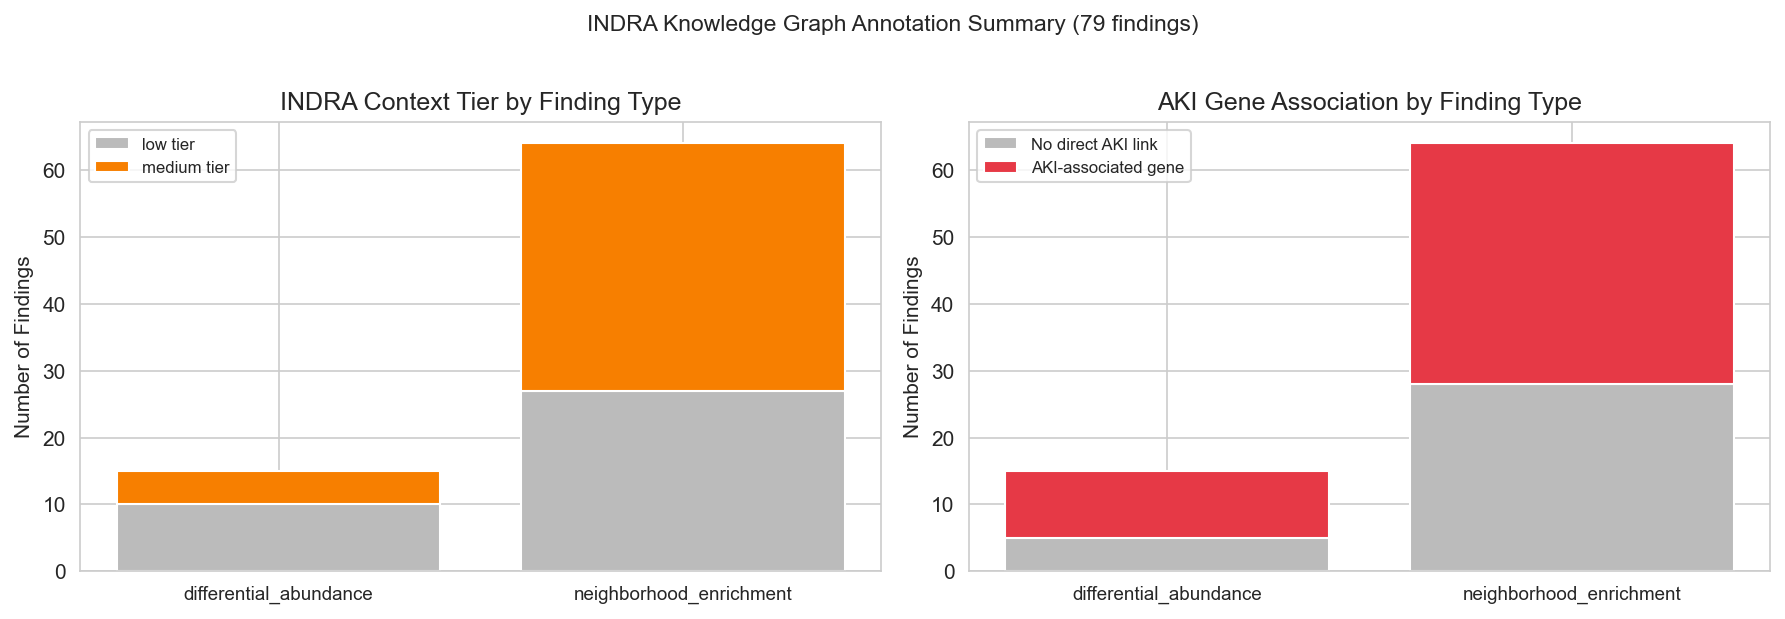

Total annotated findings: 79
  Medium-tier INDRA context: 42
  Low-tier INDRA context: 37
  AKI gene association: 46


In [18]:
# --- 5a. Finding annotation summary ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By finding type and INDRA tier
ax = axes[0]
tier_counts = indra_annot.groupby(['finding_type', 'indra_context_tier']).size().unstack(fill_value=0)
tier_colors = {'medium': '#F77F00', 'low': '#BBBBBB', 'high': '#E63946'}
bottom = np.zeros(len(tier_counts))
for tier in ['low', 'medium', 'high']:
    if tier in tier_counts.columns:
        vals = tier_counts[tier].values
        ax.bar(range(len(tier_counts)), vals, bottom=bottom,
               color=tier_colors.get(tier, '#999'), label=f'{tier} tier',
               edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(tier_counts)))
ax.set_xticklabels(tier_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('INDRA Context Tier by Finding Type')
ax.legend(fontsize=8)

# AKI gene association
ax = axes[1]
aki_counts = indra_annot.groupby(['finding_type', 'aki_gene_association']).size().unstack(fill_value=0)
aki_colors = {True: '#E63946', False: '#BBBBBB'}
bottom = np.zeros(len(aki_counts))
for has_aki in [False, True]:
    if has_aki in aki_counts.columns:
        vals = aki_counts[has_aki].values
        label = 'AKI-associated gene' if has_aki else 'No direct AKI link'
        ax.bar(range(len(aki_counts)), vals, bottom=bottom,
               color=aki_colors[has_aki], label=label, edgecolor='white')
        bottom += vals

ax.set_xticks(range(len(aki_counts)))
ax.set_xticklabels(aki_counts.index, fontsize=9)
ax.set_ylabel('Number of Findings')
ax.set_title('AKI Gene Association by Finding Type')
ax.legend(fontsize=8)

plt.suptitle(f'INDRA Knowledge Graph Annotation Summary ({len(indra_annot)} findings)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total annotated findings: {len(indra_annot)}')
print(f'  Medium-tier INDRA context: {(indra_annot["indra_context_tier"] == "medium").sum()}')
print(f'  Low-tier INDRA context: {(indra_annot["indra_context_tier"] == "low").sum()}')
print(f'  AKI gene association: {indra_annot["aki_gene_association"].sum()}')

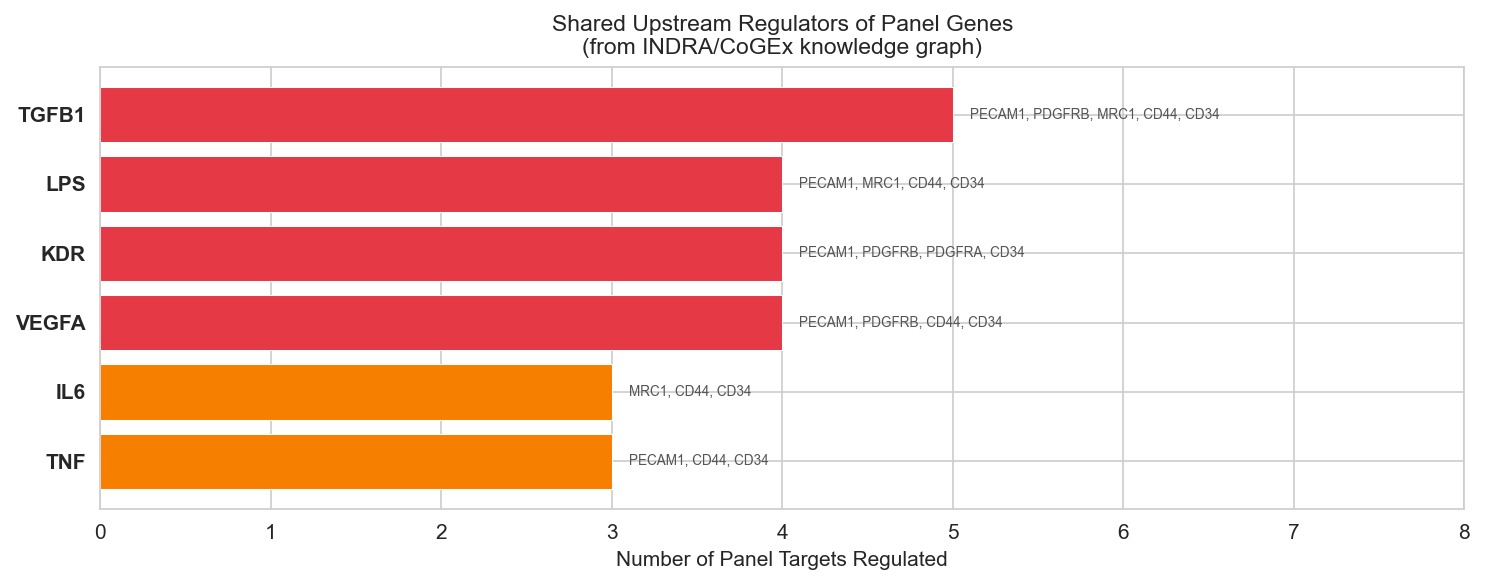

TGFB1: Master regulator of renal fibrosis. Regulates 5/8 panel genes spanning endothelial, stromal, immune, and injury axes.
LPS: Innate immune activation. Relevant to DAMP-mediated sterile inflammation in AKI.
KDR: VEGFR2 — connects VEGF signaling to endothelial and pericyte biology.
VEGFA: Vascular homeostasis and angiogenesis. Regulates both endothelial markers and injury/stromal markers.
IL6: Inflammatory cytokine; CD44 and MRC1 as targets connects injury to resolution.
TNF: Pro-inflammatory cytokine central to AKI pathogenesis.


In [19]:
# --- 5b. Upstream regulator analysis ---
regs = indra_ctx['shared_upstream_regulators']

reg_names = list(regs.keys())
reg_counts = [regs[r]['count'] for r in reg_names]
reg_relevance = [regs[r]['relevance'] for r in reg_names]

# Sort by count
order = np.argsort(reg_counts)[::-1]
reg_names = [reg_names[i] for i in order]
reg_counts = [reg_counts[i] for i in order]
reg_relevance = [reg_relevance[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
colors_reg = ['#E63946' if c >= 4 else '#F77F00' if c >= 3 else '#BBBBBB'
              for c in reg_counts]
bars = ax.barh(range(len(reg_names)), reg_counts, color=colors_reg,
               edgecolor='white', linewidth=0.5)

for i, (name, count) in enumerate(zip(reg_names, reg_counts)):
    targets = regs[name]['targets']
    target_str = ', '.join(targets)
    ax.text(count + 0.1, i, f'{target_str}', fontsize=6.5, va='center', color='#555')

ax.set_yticks(range(len(reg_names)))
ax.set_yticklabels(reg_names, fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Panel Targets Regulated')
ax.set_title('Shared Upstream Regulators of Panel Genes\n'
             '(from INDRA/CoGEx knowledge graph)', fontsize=11)
ax.invert_yaxis()
ax.set_xlim(0, 8)
plt.tight_layout()
plt.show()

# Print relevance
for name, rel in zip(reg_names, reg_relevance):
    print(f'{name}: {rel}')

In [20]:
# --- 5c. Mechanistic narratives cross-referenced with spatial data ---
narratives = indra_ctx['mechanistic_narratives']

print('=== Mechanistic Narratives from INDRA Knowledge Graph ===')
print('(cross-referenced with observed spatial enrichment)\n')

for pair_key, narrative_text in narratives.items():
    # Parse pair key (e.g., 'endothelial_endothelial' or 'macrophage_fibroblast')
    parts = pair_key.split('_')
    mid = len(parts) // 2
    focal_key = '_'.join(parts[:mid])
    neighbor_key = '_'.join(parts[mid:])

    # Try to find matching enrichment data
    enrichment_info = ''
    for _, row in temporal_enrich.iterrows():
        if (focal_key in row['focal_cell_type'] and
            neighbor_key in row['neighbor_cell_type']):
            enrichment_info = (f"  Spatial enrichment at {row['timepoint']}: "
                              f"{row['enrichment_score']:.2f}x "
                              f"(log\u2082={row['log2_enrichment']:.2f})")
            break

    print(f'\u2500\u2500\u2500 {pair_key.replace("_", " ").title()} \u2500\u2500\u2500')
    # Wrap text at 100 chars
    words = narrative_text.split()
    line = ''
    for word in words:
        if len(line) + len(word) + 1 > 100:
            print(f'  {line}')
            line = word
        else:
            line = f'{line} {word}'.strip()
    if line:
        print(f'  {line}')
    if enrichment_info:
        print(enrichment_info)
    print()

=== Mechanistic Narratives from INDRA Knowledge Graph ===
(cross-referenced with observed spatial enrichment)

─── Endothelial Endothelial ───
  Endothelial self-clustering reflects vascular network topology. CD31+/CD34+ endothelial cells in the
  peritubular capillary plexus are physically connected. PECAM1 mediates homophilic adhesion
  (GO:0007156). Both share glomerular endothelium development (GO:0072011).
  Spatial enrichment at D1: 2.06x (log₂=0.99)

─── Fibroblast Fibroblast ───
  PDGFRA+ fibroblast clustering reflects interstitial compartment organization. PDGFRA is expressed in
  kidney cortex and nephron tubule interstitium. In nephrogenesis (WP4823), fibroblasts form the
  structural scaffold of the kidney.
  Spatial enrichment at D1: 1.62x (log₂=0.63)

─── Macrophage Macrophage ───
  Myeloid cell clustering reflects immune niche formation. ITGAM+ cells accumulate at sites of injury
  via complement-mediated adhesion. MRC1+ M2 macrophages (CL:0000890) cluster in resolution 

---
## 6. Tissue Interface Composition (Phase 2 — Different Unit of Analysis)

**Shift in measurement unit.** §3-§5 operated on the **15 config-defined cell types** — each tissue patch gets ≤1 discrete label based on positive/negative markers. §6 shifts to the **continuous lineage scores** (immune, endothelial, stromal; each in [0,1] per patch). A patch is no longer "a neutrophil" or "an endothelial cell" — it has a three-number lineage vector. Thresholding that vector produces 8 interface categories: single-lineage (×3), two-way overlaps (×3), triple-positive, and none.

**This is a different question from §3.** §3 asks "how many cell-type X patches are there?" §6 asks "what fraction of tissue is at a single-lineage/multi-lineage interface?" The two are not redundant — a superpixel counted as a single discrete cell type in §3 can still score on two lineage axes in §6 when the gated cell type definition involves one lineage plus negative gates on the others. The §6 finding (stromal-only fraction decreases, triple-positive rises at Sham→D7) cannot be recovered from §3 alone.

### Pre-registered endpoint families

- **Family A — interface composition.** Mouse-level fractions of the 8 interface categories, centered log-ratio (CLR) transformed so percentages can be compared across timepoints. Two non-identical normalization paths are computed side-by-side: the Sham-reference-centered sigmoid (primary, on continuous memberships) and the raw-marker Sham-reference percentile (independent, on raw ion counts). Disagreement is reported per row as `normalization_sign_reverse` and `normalization_magnitude_disagree` in `endpoint_summary.csv`.
- **Family B — continuous neighborhood shifts.** Per composite label × neighbor lineage, mouse-level `neighbor_lineage − self_lineage` delta. Filtered for sufficient support across timepoints.
- **Family C — Sham-referenced compartment activation.** For each raw-marker compartment (CD45⁺, CD31⁺, CD140b⁺, background), mouse-level CD44⁺ rate at a Sham-reference 75ᵗʰ-percentile threshold.

### Post-hoc co-headline filter

At Sham→D7, an endpoint is retained as a co-headline if (1) direction-consistent between the Sham-reference-centered sigmoid and the raw-marker Sham-reference percentile path (Family A), or uses Sham-reference by design (Family C); (2) |g| > 0.5 in the primary path; (3) the two paths do not disagree by ≥2× in magnitude (symmetric `normalization_magnitude_disagree` flag). The code cell below applies this filter, shows shrunk effect sizes under three Bayesian priors, and lists the full accounting of endpoints filtered out. Source: `endpoint_summary.csv`.

In [21]:
# --- 6a. Phase 2 Sham→D7 co-headline endpoints from endpoint_summary.csv ---
endpoint = pd.read_csv(project_root / 'results/biological_analysis/temporal_interfaces/endpoint_summary.csv')

# Bool columns come in as strings from the CSV — coerce explicitly
# CSV stores these as mixed bool/NaN (NaN for rows where the flag doesn't apply).
# Coerce to strict bool: True stays True, False/NaN become False.
for col in ['normalization_sign_reverse', 'normalization_g_collapse',
            'normalization_magnitude_disagree', 'g_pathological', 'insufficient_support']:
    if col in endpoint.columns:
        endpoint[col] = (endpoint[col] == True)

sham_d7 = endpoint[endpoint['contrast'] == 'Sham_vs_D7'].copy()

# Family A co-headlines: per-ROI regime + direction-consistent + symmetric-magnitude-agreement + |g|>0.5.
# The symmetric `normalization_magnitude_disagree` flag replaced the earlier asymmetric
# `normalization_g_collapse` (Phase 1 brutalist: the asymmetric metric understates disagreement).
fA_per_roi = sham_d7[(sham_d7['family']=='A_interface_clr') & (sham_d7['normalization_mode']=='per_roi_sigmoid')]
co_A = fA_per_roi[
    (~fA_per_roi['normalization_sign_reverse']) &
    (~fA_per_roi['normalization_magnitude_disagree']) &
    (fA_per_roi['hedges_g'].abs() > 0.5)
].copy()

# Family C: Sham-reference by design; filter to substantive effect sizes
fC = sham_d7[sham_d7['family']=='C_compartment_activation']
co_C = fC[fC['hedges_g'].abs() > 0.5].copy()

co = pd.concat([co_C, co_A], ignore_index=True).sort_values('hedges_g', key=abs, ascending=False)

display_cols = ['family', 'endpoint', 'hedges_g', 'g_shrunk_skeptical', 'g_shrunk_neutral',
                'g_shrunk_optimistic', 'n_required_skeptical', 'n_required_neutral', 'n_required_optimistic']
disp = co[display_cols].copy()
disp.columns = ['family', 'endpoint', 'g_raw', 'g_skep', 'g_neut', 'g_opt',
                'n_req_skep', 'n_req_neut', 'n_req_opt']

print('Co-headline endpoints at Sham vs D7 (post-hoc selection)')
print('=' * 110)
with pd.option_context('display.max_colwidth', 45, 'display.float_format', '{:.2f}'.format):
    print(disp.to_string(index=False))
print()

# Full accounting of Family A endpoints filtered out (transparency)
reversers = fA_per_roi[fA_per_roi['normalization_sign_reverse']]
magdisagree = fA_per_roi[fA_per_roi['normalization_magnitude_disagree']]
near_zero = fA_per_roi[(~fA_per_roi['normalization_sign_reverse']) &
                       (~fA_per_roi['normalization_magnitude_disagree']) &
                       (fA_per_roi['hedges_g'].abs() <= 0.5)]
print('Family A endpoints filtered OUT of co-headlines (full accounting):')
print(f'  sign-reverse between Sham-ref sigmoid and raw-marker Sham-ref paths: {len(reversers)}')
for _, r in reversers.iterrows():
    print(f'    {r["endpoint"]:40s} sigmoid g={r["hedges_g"]:+.2f}  raw-marker g={r["hedges_g_sham_ref"]:+.2f}')
print(f'  magnitude disagreement (>=2x, symmetric): {len(magdisagree)}')
for _, r in magdisagree.iterrows():
    print(f'    {r["endpoint"]:40s} sigmoid g={r["hedges_g"]:+.2f}  raw-marker g={r["hedges_g_sham_ref"]:+.2f}')
print(f'  near-zero (|g| <= 0.5 in sigmoid): {len(near_zero)}')
for _, r in near_zero.iterrows():
    print(f'    {r["endpoint"]:40s} sigmoid g={r["hedges_g"]:+.2f}')

# --- Phase 2 additive disclosure: rank-based top-5 (Seam 2) ---
# Selection-free alternative to the threshold-filtered co-headline table.
# Ranked on |g_shrunk_neutral| (not raw |g|) so pooled-SD-collapse artifacts
# at n=2 don't float to the top; pathological rows (|g|>3 AND
# pooled_std<0.01) are explicitly flagged and their shrunken values are NaN.
try:
    rank_tbl = pd.read_csv(da_dir / 'temporal_top_ranked_by_effect.csv')
    print()
    print('Rank-based top-5 (ranked on |g_shrunk_neutral|; Sham vs D7):')
    print('=' * 110)
    rank_d7 = rank_tbl[rank_tbl['comparison'] == 'Sham_vs_D7'][
        ['rank', 'cell_type', 'hedges_g', 'g_shrunk_neutral', 'g_pathological']
    ]
    print(rank_d7.to_string(index=False))
    path_count = rank_tbl['g_pathological'].sum()
    if path_count:
        print(f'\n  {int(path_count)} endpoint(s) quarantined as pathological across all contrasts.')
except FileNotFoundError:
    print('rank table not available (regenerate differential_abundance)')

# Seam 3 note: the earlier draft emitted a `_density_per_mm2` column intended
# as non-compositional corroboration, but brutalist review verified it reduced
# to 2500 × proportion (tissue_area_mm2 came from the SLIC target density,
# which is constant up to ~2% ROI-to-ROI noise). That surface is now removed.
# The genuine non-compositional corroboration for Family A CLR endpoints lives
# in Family C (raw-marker CD44+ compartment rates) — already in the
# co-headline table above. Future work: rebuild density from the actual DNA
# segmentation-mask area rather than the SLIC target constant.


Co-headline endpoints at Sham vs D7 (post-hoc selection)
                  family                         endpoint  g_raw  g_skep  g_neut  g_opt  n_req_skep  n_req_neut  n_req_opt
         A_interface_clr   endothelial+immune+stromal_clr   3.40    0.32    0.99   2.11      158.00       17.00       4.00
C_compartment_activation          triple_overlap_fraction   3.31    0.32    0.98   2.08      158.00       17.00       4.00
C_compartment_activation background_compartment_cd44_rate   2.88    0.31    0.95   1.91      159.00       18.00       5.00
C_compartment_activation     CD140b_compartment_cd44_rate   1.46    0.24    0.64   1.11      271.00       38.00      13.00
         A_interface_clr           endothelial+immune_clr   1.17    0.21    0.54   0.90      372.00       55.00      20.00
         A_interface_clr               immune+stromal_clr   1.07    0.19    0.50   0.83      427.00       64.00      23.00
         A_interface_clr                       immune_clr  -0.80   -0.15   -0.39  

### Reading the candidate finding

The co-headline endpoints above converge on a single story: **at Sham→D7, stromal-marker-positive tissue is classified less often as stromal-only and more often as multi-lineage.** Three pre-registered endpoint families with different measurement geometries support this reading.

- **Family A — interface composition (CLR on a closed simplex).** Stromal-only CLR decreases (-1.59 raw, neutral-shrunk -0.69); triple-positive (`endothelial+immune+stromal`) CLR increases (+0.63 raw, neutral-shrunk +0.99). On the closed simplex these are *mathematically coupled* — one degree of freedom dressed as two observations. Family A alone is insufficient.
- **Family B — neighbor-minus-self delta (graph-topological).** Phase 6 reports two co-primary lineage-source bases: a sigmoid Sham-reference basis and a raw arcsinh basis (sigmoid-independent because the neighbor-minus-self operation is differential and the Sham offset cancels). At Sham→D7, **14 endpoints** clear `|g_shrunk_neutral|>0.5` in both bases with same sign (the conservative-intersection headline set), 7 are sigmoid-only, 4 are raw-only, 0 are opposite-sign-same-endpoint. Top raw-basis rows: neighbors of stromal- and activated-endothelial-CD44-labeled superpixels acquire more immune-marker signal at D7. *Different measurement geometry from Family A* — graph topology vs simplex composition.
- **Family C — compartment activation (per-compartment rate).** Triple-overlap fraction (+0.98 neutral-shrunk), background-compartment CD44⁺ rate (+0.95), CD140b-compartment CD44⁺ rate (+0.64). Uses partly different markers from Family A (CD140b vs CD140a; CD31 alone vs mean(CD31, CD34)) and a per-compartment-rate geometry rather than CLR composition. *Independent of CLR closure*; non-CLR corroboration.

The three families converge on the redistribution reading despite not sharing measurement geometry with each other. That convergence is **consistent with** the candidate finding, not statistical independence: all three families anchor on the same n=2 Sham distribution × 3 ROIs, so sign agreement is partly built-in. The symmetric magnitude-disagreement count for Family A (13/48 endpoints) and the Family B basis-divergence breakdown are the honest upper bounds on how much independent measurement remains in this cohort. Phase 5.1 retracted the area-based-density alternative empirically — every ROI is acquired at the same ~500×500 µm field, making `tissue_area_mm2` dataset-constant.

**This is convergent evidence, not demonstrated mechanism.** No lineage tracing. No object-level transition analysis. CD44 is broadly expressed under tissue injury (Family C is explicitly pan-tissue activation, not lineage-specific). The companion kidney notebook (`notebooks/biological_narratives/kidney_injury_spatial_analysis.ipynb`) Parts 2, 2.5, and 6 visualize the three families' Sham→D7 trajectories.

**The immune story needs more care than the CLR column alone suggests.** `immune_clr` survives the filter with neutral-shrunk g = −0.39 (pure immune tissue is proportionally less prominent at D7). The discrete `immune_cells` row in the rank-based companion table is `g_pathological=True` (|g|=3.98 with pooled_std=0.00128 — variance-collapse artifact, not a real effect). Read the immune-redistribution claim as: pure-immune tissue *fraction* falls and immune neighbors *spread* into multi-lineage interfaces, consistent with the Family B raw-basis finding that activated-endothelial-CD44 superpixels acquire more immune neighbor signal at D7.


In [22]:
# --- Combined evidence table (Layer A cell types × INDRA + self-enrichment) ---
# NOTE: This table draws from Layer A (`temporal_da`, 15 config cell types) joined
# with Layer A INDRA annotations. It is a §3+§4+§5 summary, placed here for
# reader convenience before the §7 power section — it is NOT a Phase 2 finding.
# Merge temporal DA with INDRA annotations
da_annotated = temporal_da.copy()
da_annotated['abs_g'] = da_annotated['hedges_g'].abs()
da_top = da_annotated.nlargest(10, 'abs_g')

# Cross-reference with INDRA annotations
rows_out = []
for _, row in da_top.iterrows():
    ct = row['cell_type']
    # Find matching INDRA annotation
    indra_match = indra_annot[
        (indra_annot['cell_type'] == ct) &
        (indra_annot['finding_type'] == 'differential_abundance')
    ]
    tier = indra_match['indra_context_tier'].values[0] if len(indra_match) > 0 else '-'
    n_evidence = indra_match['indra_evidence_count'].values[0] if len(indra_match) > 0 else 0
    aki = indra_match['aki_gene_association'].values[0] if len(indra_match) > 0 else False

    # Find self-enrichment for this cell type (mean across timepoints)
    self_e = self_enrich[self_enrich['focal_cell_type'] == ct]['enrichment_score'].mean()

    rows_out.append({
        'Cell Type': ct_label(ct),
        'Comparison': row['comparison'],
        'Hedges g': f"{row['hedges_g']:.2f}",
        'Bootstrap range': f"[{row['bootstrap_range_min']:.1f}, {row['bootstrap_range_max']:.1f}]",
        'q-value': f"{row['p_value_fdr']:.2f}",
        'INDRA Tier': tier,
        'INDRA Evidence': int(n_evidence) if not pd.isna(n_evidence) else 0,
        'AKI Assoc.': 'Yes' if aki else 'No',
        'Self-Enrichment': f'{self_e:.2f}x' if not np.isnan(self_e) else '-',
    })

evidence_df = pd.DataFrame(rows_out)
print('Top 10 Hypothesis-Generating Findings by Effect Size Magnitude')
print('=' * 100)
print(evidence_df.to_string(index=False))
print('\nAll q > 0.05 (no FDR-significant findings at n=2).')
print('Effect sizes provided for follow-up study power calculations.')

Top 10 Hypothesis-Generating Findings by Effect Size Magnitude
                      Cell Type Comparison Hedges g Bootstrap range q-value INDRA Tier  INDRA Evidence AKI Assoc. Self-Enrichment
                   Immune Cells   D1_vs_D7    11.91   [11.9, 114.9]    0.50          -               0         No           1.92x
                     Fibroblast   D1_vs_D7    10.35    [10.3, 96.4]    0.50          -               0         No           1.88x
              Endothelial Cells Sham_vs_D3    -7.20   [-14.4, -7.2]    0.50          -               0         No           1.65x
Activated Endothelial (CD140b+) Sham_vs_D3    -5.30   [-12.1, -5.3]    0.50          -               0         No           2.26x
      Activated Myeloid (CD44+)   D1_vs_D3     4.21      [4.2, 8.6]    0.50          -               0         No           2.66x
      Activated Myeloid (CD44+)   D1_vs_D7     4.07     [4.1, 16.1]    0.50          -               0         No           2.66x
                   Immune C

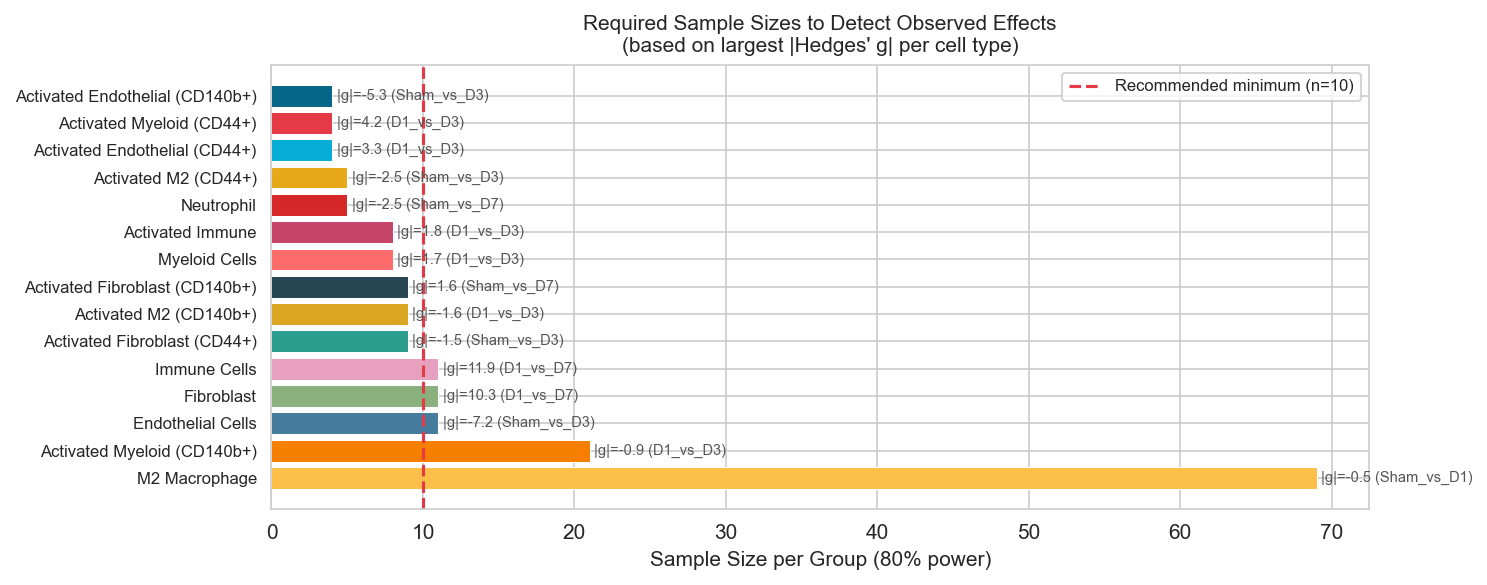

In [23]:
# --- 6b. Power analysis ---
if power_df is not None and len(power_df) > 0:
    power_sorted = power_df.sort_values('n_required_80pct')

    fig, ax = plt.subplots(figsize=(10, 4))
    colors_pwr = [CT_COLORS.get(ct, '#999') for ct in power_sorted['cell_type']]
    bars = ax.barh(range(len(power_sorted)), power_sorted['n_required_80pct'],
                   color=colors_pwr, edgecolor='white', linewidth=0.5)

    for i, (_, row) in enumerate(power_sorted.iterrows()):
        ax.text(row['n_required_80pct'] + 0.3, i,
                f"|g|={row['max_hedges_g']:.1f} ({row['comparison_at_max']})",
                fontsize=7, va='center', color='#555')

    ax.axvline(10, color='#E63946', linestyle='--', linewidth=1.5,
               label='Recommended minimum (n=10)')
    ax.set_yticks(range(len(power_sorted)))
    ax.set_yticklabels([ct_label(ct) for ct in power_sorted['cell_type']], fontsize=8)
    ax.set_xlabel('Sample Size per Group (80% power)')
    ax.set_title('Required Sample Sizes to Detect Observed Effects\n'
                 '(based on largest |Hedges\' g| per cell type)', fontsize=10)
    ax.legend(fontsize=8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Power analysis data not available.')

## 7. Follow-Up Study Design

### Candidate endpoints ranked by robustness

The §6a table above lists the endpoints that survive the post-hoc normalization filter. Read the table directly for the quantities; this section interprets it.

**Large-effect, robust under both normalization regimes (|g| > 1):**
- `triple_overlap_fraction` Sham→D7 (Family C; Sham-reference by design)
- `background_compartment_cd44_rate` Sham→D7 (Family C; largest raw effect at g = +2.82)
- `stromal_clr` Sham→D7 (Family A; direction-consistent, strengthens under Sham-reference from per-ROI g = −1.59 to Sham-ref g = −3.20)
- `CD140b_compartment_cd44_rate` Sham→D7 (Family C)

**Small-effect, robust but wider uncertainty (0.5 < |g| < 1):**
- `endothelial+immune+stromal_clr` Sham→D7 (Family A; amplifies under Sham-reference from per-ROI g = +0.63 to Sham-ref g = +2.08)
- `immune_clr` Sham→D7 (Family A; marginal, g = −0.53; read as CLR-closure corroboration, not an independent finding — see §6 interpretation)

**Normalization-fragile (methodological evidence, do NOT power follow-up around these):**
- `endothelial_clr` Sham→D7 — per-ROI |g| = 2.28 collapses to Sham-ref |g| = 0.19. Evidence that normalization choice materially affects CLR conclusions — NOT evidence that Sham-reference is artifact-free.
- `endothelial+immune_clr`, `immune+stromal_clr`, `none_clr` — sign-reverse between regimes
- Family B (continuous neighborhood) — 100% threshold-sensitive across the min-support sweep at n=2. Defer until cohort supports stable filtering.

### Sample-size budget

Use the `n_req_skep / n_req_neut / n_req_opt` columns in the §6a table.

**For a pre-clinical follow-up grant, use the neutral prior (N(0, 1²)) as the planning default.** It sits at the center of the three-prior sensitivity analysis and assumes the true effect is probably real but half the observed magnitude — the standard Bayesian shrinkage for a noisy pilot. Under this prior, the four large-effect headline endpoints require **17–39 mice per timepoint** for 80% power. Report the skeptical and optimistic priors as a sensitivity band (150–280 mice per timepoint under N(0, 0.5²); 4–14 under N(0, 2²)) — the factor-of-10 spread honestly represents what n=2 can and cannot tell you.

For a proof-of-concept replication (low-risk, pilot-scale budget), the optimistic prior is defensible. For a pivotal confirmatory study, use the skeptical prior. In no case does any single prior *solve* the problem — n=2 precludes that.

### The biggest methodological change to make upstream

**Switch the cell type annotation engine to a Sham-reference threshold** rather than per-ROI sigmoid normalization. Gate 6 showed that per-ROI normalization can manufacture apparent CLR shifts (as in `endothelial_clr`, which collapses from g = +2.28 to +0.19 when normalization is switched) and compress real ones (as in `endothelial+immune+stromal_clr`, which amplifies from +0.63 to +2.08 under Sham-reference). This fix is upstream of every downstream effect size; without it, each Phase 2 CLR endpoint carries a confound that no additional cohort size can resolve.

### Other design parameters for the follow-up

- **n ≥ 20 mice per timepoint** to exceed the neutral-prior requirement with margin (the large-effect endpoints require 17–39, so ~20 is the minimum honest budget; aim higher for the small-effect endpoints)
- **Expanded panel (≥ 20 markers)**: tubular epithelium (E-cadherin, aquaporin, KIM-1), T/B cell subsets (CD3, CD4, CD8, CD20), additional macrophage polarization markers. Reduces the ~22% tissue not visible to the current panel.
- **Longitudinal where feasible**: same animals across timepoints via survival surgery, to separate biological variability from temporal progression
- **Regional stratification**: paired Wilcoxon signed-rank for cortex-vs-medulla comparisons from the same mouse (currently unpaired)
- **Pathway enrichment becomes feasible** at 20+ markers (precluded at n=8 groundable genes in the current panel)

---
*Pipeline: IMC .txt → arcsinh → SLIC superpixels (10 µm) → dual annotation (discrete gating + continuous memberships) → Phase 1 differential abundance + neighborhood enrichment → Phase 2 temporal interface analysis (3 families, Bayesian shrinkage under 3 priors, Hedges & Olkin 1985 variance, Sham-reference sensitivity) → INDRA/CoGEx knowledge-graph annotation. See `METHODS.md` and `analysis_plans/temporal_interfaces_plan.md`.*

*Methods validation: `notebooks/methods_validation/benchmarks/steinbock_concordance.ipynb` (data-I/O integrity), `notebooks/methods_validation/01_technical_methods/gradient_discretization.ipynb` (discretization trade-offs).*